# Deep Learning - Clasificación de Lesiones Cutáneas

**Autores:** David Moreda Amezcua, Javier Cerón Contreras, Pedro Martínez Huertas

**Máster en Inteligencia Artificial - Universidad Loyola**

# 0. Creación del dataset de imágenes

In [3]:
import os
import pandas as pd
import shutil

BASE = "/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos"
IMG_SRC = os.path.join(BASE, "images", "MULTICLASE")
IMG_DST = os.path.join(BASE, "images", "SPLIT_MULTICLASE")

df_train = pd.read_csv(os.path.join(BASE, "Train_clean.csv"))
df_test = pd.read_csv(os.path.join(BASE, "Test_clean.csv"))

class_names = {0: "ACK", 1: "BCC", 2: "MEL", 3: "NEV", 4: "SCC", 5: "SEK"}
binary_names = {0: "Benigno", 1: "Maligno"}
splits = {"train": df_train, "test": df_test}



for split_name in splits:
    for class_name in class_names.values():
        os.makedirs(os.path.join(BASE, "images", "SPLIT_MULTICLASE", split_name, class_name), exist_ok=True)
    for bin_name in binary_names.values():
        os.makedirs(os.path.join(BASE, "images", "SPLIT_BINARIO", split_name, bin_name), exist_ok=True)

for split_name, df in splits.items():
    for _, row in df.iterrows():
        diag = row["diagnostic"]
        diag_bin = row["diagnostic_binario"]
        multi_name = class_names[diag]
        bin_name = binary_names[diag_bin]

        for img_name in str(row["img_id"]).split(", "):
            img_name = img_name.strip()
            src = os.path.join(IMG_SRC, multi_name, img_name)
            if not os.path.exists(src):
                print(f"No encontrada: {src}")
                continue
            dst_multi = os.path.join(BASE, "images", "SPLIT_MULTICLASE", split_name, multi_name, img_name)
            shutil.copy2(src, dst_multi)
            dst_bin = os.path.join(BASE, "images", "SPLIT_BINARIO", split_name, bin_name, img_name)
            shutil.copy2(src, dst_bin)
print("=== MULTICLASE ===")
for split_name in splits:
    print(f"\n{split_name}:")
    for class_name in class_names.values():
        path = os.path.join(BASE, "images", "SPLIT_MULTICLASE", split_name, class_name)
        print(f"  {class_name}: {len(os.listdir(path))}")

print("\n=== BINARIO ===")
for split_name in splits:
    print(f"\n{split_name}:")
    for bin_name in binary_names.values():
        path = os.path.join(BASE, "images", "SPLIT_BINARIO", split_name, bin_name)
        print(f"  {bin_name}: {len(os.listdir(path))}")


=== MULTICLASE ===

train:
  ACK: 120
  BCC: 118
  MEL: 44
  NEV: 122
  SCC: 123
  SEK: 122

test:
  ACK: 30
  BCC: 32
  MEL: 8
  NEV: 28
  SCC: 27
  SEK: 28

=== BINARIO ===

train:
  Benigno: 364
  Maligno: 285

test:
  Benigno: 86
  Maligno: 67


## 1. Análisis Exploratorio del Dataset

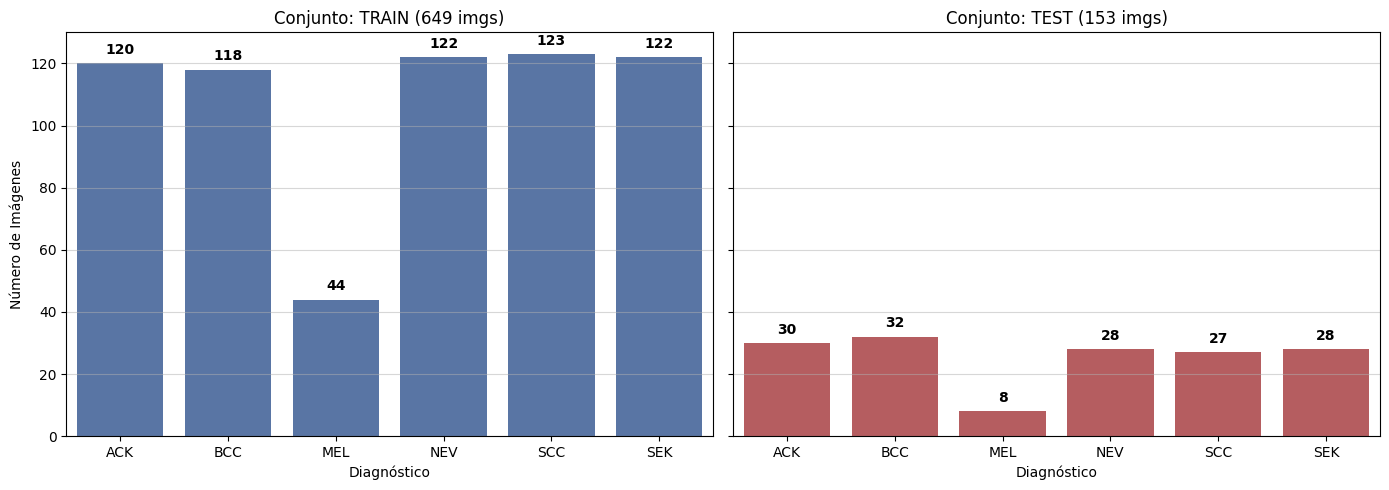


Resumen de Tamaños:
Medio: 890x890
Mínimo: 147x147
Máximo: 3474x3476


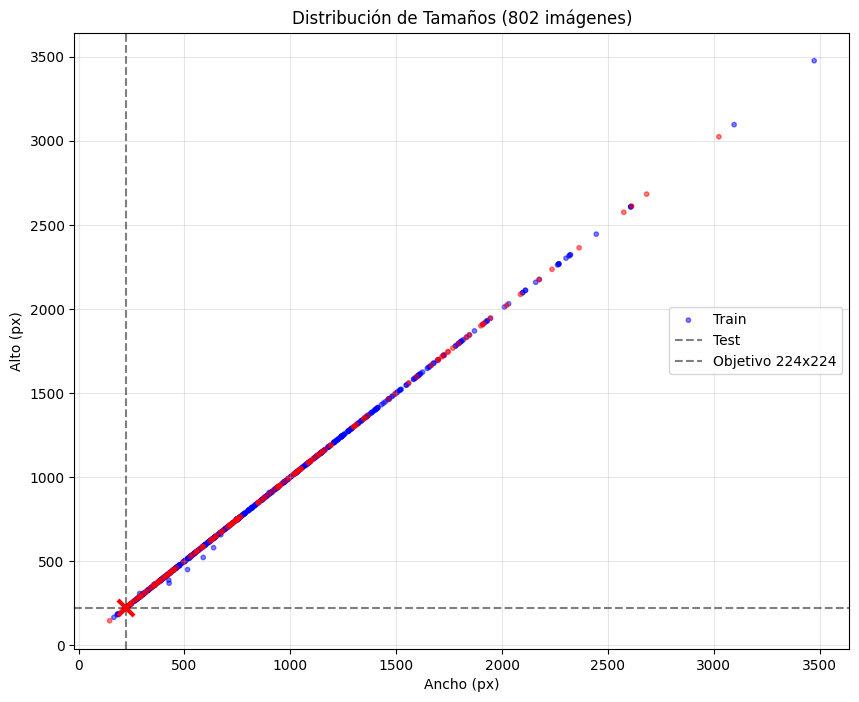

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
from tqdm import tqdm

RUTA_RAIZ = "../../Datos/images/SPLIT_MULTICLASE"
splits = ["train", "test"]
colores = ["#4c72b0", "#c44e52"]

# --- Distribución de clases ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, split in enumerate(splits):
    split_path = os.path.join(RUTA_RAIZ, split)
    clases = sorted(os.listdir(split_path))
    conteo = {c: len(os.listdir(os.path.join(split_path, c))) for c in clases}
    total = sum(conteo.values())

    sns.barplot(x=list(conteo.keys()), y=list(conteo.values()), ax=axes[i], color=colores[i])
    axes[i].set_title(f"Conjunto: {split.upper()} ({total} imgs)")
    axes[i].set_xlabel("Diagnóstico")
    axes[i].grid(axis="y", alpha=0.5)
    axes[i].set_ylim(0, 130)

    for idx, (clase, valor) in enumerate(conteo.items()):
        axes[i].text(idx, valor + 3, str(valor), ha="center", fontweight="bold")

axes[0].set_ylabel("Número de Imágenes")
plt.tight_layout()
plt.show()

# --- Tamaño de imágenes ---
anchos = []
altos = []
colores_puntos = []
mapa_colores = {"train": "blue", "test": "red"}

for split in splits:
    split_path = os.path.join(RUTA_RAIZ, split)
    clases = sorted(os.listdir(split_path))
    for clase in clases:
        clase_path = os.path.join(split_path, clase)
        archivos = [f for f in os.listdir(clase_path) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
        for nombre in tqdm(archivos, desc=f"{split}/{clase}", leave=False):
            ruta_completa = os.path.join(clase_path, nombre)
            with Image.open(ruta_completa) as img:
                w, h = img.size
                anchos.append(w)
                altos.append(h)
                colores_puntos.append(mapa_colores[split])

plt.figure(figsize=(10, 8))
plt.scatter(anchos, altos, c=colores_puntos, alpha=0.5, s=10)
plt.axvline(224, color="k", linestyle="--", alpha=0.5)
plt.axhline(224, color="k", linestyle="--", alpha=0.5)
plt.plot(224, 224, "rx", markersize=12, markeredgewidth=3)
plt.title(f"Distribución de Tamaños ({len(anchos)} imágenes)")
plt.xlabel("Ancho (px)")
plt.ylabel("Alto (px)")
plt.legend(["Train", "Test", "Objetivo 224x224"])
plt.grid(True, alpha=0.3)

print(f"\nResumen de Tamaños:")
print(f"Medio: {sum(anchos)//len(anchos)}x{sum(altos)//len(altos)}")
print(f"Mínimo: {min(anchos)}x{min(altos)}")
print(f"Máximo: {max(anchos)}x{max(altos)}")

plt.show()


### Conclusiones del EDA y Estrategia de Evaluación

**1. Análisis del Dataset**
*   **Desbalanceo Crítico:** Se ha identificado un desbalanceo significativo donde la clase MEL (Melanoma) es minoritaria frente a otras como NV (Nevus). Esto presenta un desafío importante, ya que induce al modelo a sesgar sus predicciones hacia las clases mayoritarias, ignorando los casos positivos de melanoma.
*   **Volumen de Datos Limitado:** El conjunto de entrenamiento contiene aproximadamente 650 imágenes. Este volumen es insuficiente para entrenar redes profundas desde cero sin riesgo de *overfitting*, lo que hace imprescindible el uso de técnicas de *Transfer Learning* y un *Data Augmentation* robusto.
*   **Consistencia en Dimensiones:** Las imágenes mantienen proporciones similares, validando el redimensionado directo a **224x224** píxeles sin pérdida significativa de información morfológica.

**2. Estrategia de Evaluación Clínica**
Debido a la naturaleza médica del problema y al desbalanceo de clases, la métrica de *Accuracy* global se descarta como indicador principal de rendimiento. La evaluación se basará en:

*   **F1-Score Macro:** Será la métrica principal de optimización. Al promediar el rendimiento por clase sin ponderar por número de muestras, penaliza fuertemente al modelo si falla en la detección de la clase minoritaria (MEL), obligándolo a generalizar correctamente en todos los diagnósticos.
*   **Sensibilidad (Recall) para MEL:** Desde una perspectiva clínica, la prioridad es minimizar los falsos negativos. Un alto Recall en la clase Melanoma garantiza que se detecten la mayor cantidad posible de casos malignos, priorizando la seguridad del paciente sobre la precisión pura.
*   **Matriz de Confusión:** Se utilizará para analizar los patrones de error específicos y entender con qué lesiones benignas se está confundiendo el melanoma.

## 3.Hiperparametrización con optuna

Tras realizar pruebas congelando distintas capas y haciendo tuning manual de hiperparámetros encontramos unos rangos de valores dónde los modelos funcionanaban y decidimos hacer una hiperparametrización con optuna.

📊 VISUALIZACIÓN DE HIPERPARAMETRIZACIÓN - TODOS LOS MODELOS

🔍 Cargando estudios de Optuna...
  ✅ ResNet18: 20 trials
  ✅ DenseNet121: 20 trials
  ✅ YOLO26x: 30 trials

📈 Generando gráfica: Evolución de scores...



🎨 Generando gráficas: Combinaciones de hiperparámetros...


  ✅ ResNet18


  ✅ DenseNet121


  ✅ YOLO26x

📊 ESTADÍSTICAS DE TRIALS

     Modelo  Total Trials  Completados  Podados  Fallidos % Completados
   ResNet18            20           12        8         0         60.0%
DenseNet121            20           17        3         0         85.0%
    YOLO26x            30           10       20         0         33.3%

🏆 MEJORES HIPERPARÁMETROS POR MODELO

────────────────────────────────────────────────────────────────────────────────
📌 RESNET18
────────────────────────────────────────────────────────────────────────────────
🏆 Mejor Score: 0.5600
🔢 Mejor Trial: #0

📝 Hiperparámetros:
   • batch_size          : 16
   • dropout             : 0.300000
   • lr_backbone         : 0.000131
   • lr_head             : 0.000437
   • weight_decay        : 0.002365

────────────────────────────────────────────────────────────────────────────────
📌 DENSENET121
────────────────────────────────────────────────────────────────────────────────
🏆 Mejor Score: 0.5550
🔢 Mejor Trial: #14

📝 Hiperp

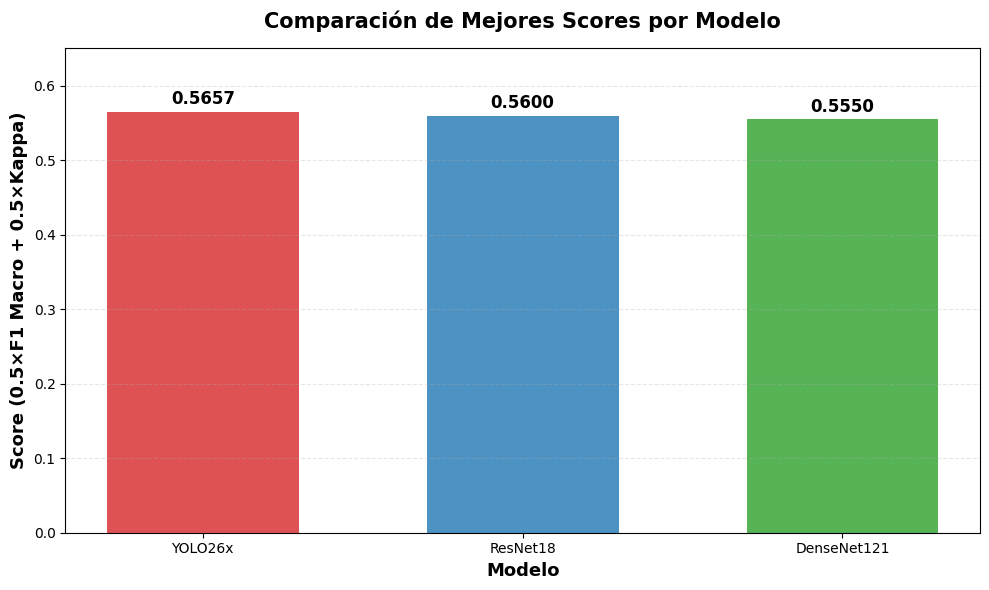


✅ VISUALIZACIÓN COMPLETADA



In [2]:
"""
Visualización de hiperparametrización - ResNet18, DenseNet121, YOLO26x
"""

import optuna
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Configuración
DB_RESNET_DENSENET = "hyperparameters/hyperparameter_tuning.db"
DB_YOLO = "hyperparameters/yolo_tuning.db"

print("="*80)
print("📊 VISUALIZACIÓN DE HIPERPARAMETRIZACIÓN - TODOS LOS MODELOS")
print("="*80)

# ============================================================================
# 1. CARGAR ESTUDIOS
# ============================================================================

print("\n🔍 Cargando estudios de Optuna...")

storage_resnet = f"sqlite:///{DB_RESNET_DENSENET}"
try:
    study_resnet = optuna.load_study(study_name="resnet18_tuning", storage=storage_resnet)
    print(f"  ✅ ResNet18: {len(study_resnet.trials)} trials")
except:
    print(f"  ❌ ResNet18 no encontrado")
    study_resnet = None

try:
    study_densenet = optuna.load_study(study_name="densenet121_tuning", storage=storage_resnet)
    print(f"  ✅ DenseNet121: {len(study_densenet.trials)} trials")
except:
    print(f"  ❌ DenseNet121 no encontrado")
    study_densenet = None

storage_yolo = f"sqlite:///{DB_YOLO}"
try:
    study_yolo = optuna.load_study(study_name="yolo26x-cls_tuning", storage=storage_yolo)
    print(f"  ✅ YOLO26x: {len(study_yolo.trials)} trials")
except:
    print(f"  ❌ YOLO26x no encontrado")
    study_yolo = None

def get_completed_trials(study):
    if study is None:
        return []
    return [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]

# ============================================================================
# 2. GRÁFICA: EVOLUCIÓN DE SCORES
# ============================================================================

print("\n📈 Generando gráfica: Evolución de scores...")

studies = {
    'ResNet18': study_resnet,
    'DenseNet121': study_densenet,
    'YOLO26x': study_yolo
}

colors = {'ResNet18': '#1f77b4', 'DenseNet121': '#2ca02c', 'YOLO26x': '#d62728'}

fig = go.Figure()

for model_name, study in studies.items():
    if study is None:
        continue
    
    completed = get_completed_trials(study)
    if not completed:
        continue
    
    trial_numbers = [t.number for t in completed]
    scores = [t.value for t in completed]
    
    # Trials
    fig.add_trace(go.Scatter(
        x=trial_numbers, y=scores,
        mode='markers+lines',
        name=f'{model_name}',
        marker=dict(size=8, color=colors[model_name]),
        line=dict(color=colors[model_name], width=2, dash='dot'),
        opacity=0.6
    ))
    
    # Best so far
    best_so_far = []
    current_best = -float('inf')
    for score in scores:
        current_best = max(current_best, score)
        best_so_far.append(current_best)
    
    fig.add_trace(go.Scatter(
        x=trial_numbers, y=best_so_far,
        mode='lines',
        name=f'{model_name} (best)',
        line=dict(color=colors[model_name], width=3),
        opacity=0.9
    ))

fig.update_layout(
    title='Evolución de Scores en Hiperparametrización',
    xaxis_title='Trial Number',
    yaxis_title='Score (0.5×F1 Macro + 0.5×Kappa)',
    hovermode='closest',
    template='plotly_white',
    height=600,
    font=dict(size=12)
)
fig.show()

# ============================================================================
# 3. GRÁFICAS: PARALLEL COORDINATES (Combinaciones de hiperparámetros)
# ============================================================================

print("\n🎨 Generando gráficas: Combinaciones de hiperparámetros...")

for model_name, study in studies.items():
    if study is None or len(get_completed_trials(study)) < 3:
        continue
    
    try:
        fig = optuna.visualization.plot_parallel_coordinate(study)
        fig.update_layout(
            title=f'Combinaciones de Hiperparámetros - {model_name}',
            height=500
        )
        fig.show()
        print(f"  ✅ {model_name}")
    except Exception as e:
        print(f"  ⚠️  Error en {model_name}: {e}")

# ============================================================================
# 4. TABLA: ESTADÍSTICAS DE TRIALS
# ============================================================================

print("\n" + "="*80)
print("📊 ESTADÍSTICAS DE TRIALS")
print("="*80)

stats_data = []

for model_name, study in studies.items():
    if study is None:
        continue
    
    completed = get_completed_trials(study)
    total = len(study.trials)
    pruned = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)
    failed = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.FAIL)
    
    stats_data.append({
        'Modelo': model_name,
        'Total Trials': total,
        'Completados': len(completed),
        'Podados': pruned,
        'Fallidos': failed,
        '% Completados': f"{len(completed)/total*100:.1f}%"
    })

df_stats = pd.DataFrame(stats_data)
print("\n" + df_stats.to_string(index=False))

# ============================================================================
# 5. RESUMEN: MEJORES HIPERPARÁMETROS
# ============================================================================

print("\n" + "="*80)
print("🏆 MEJORES HIPERPARÁMETROS POR MODELO")
print("="*80)

results_summary = []

for model_name, study in studies.items():
    if study is None:
        continue
    
    completed = get_completed_trials(study)
    if not completed:
        continue
    
    best_trial = study.best_trial
    
    print(f"\n{'─'*80}")
    print(f"📌 {model_name.upper()}")
    print(f"{'─'*80}")
    print(f"🏆 Mejor Score: {best_trial.value:.4f}")
    print(f"🔢 Mejor Trial: #{best_trial.number}")
    print(f"\n📝 Hiperparámetros:")
    
    for param, value in sorted(best_trial.params.items()):
        if isinstance(value, float):
            print(f"   • {param:20s}: {value:.6f}")
        else:
            print(f"   • {param:20s}: {value}")
    
    results_summary.append({
        'Modelo': model_name,
        'Score': best_trial.value
    })

# ============================================================================
# 6. GRÁFICA: COMPARACIÓN DE SCORES (MATPLOTLIB)
# ============================================================================

if results_summary:
    print("\n" + "="*80)
    print("📊 COMPARACIÓN FINAL")
    print("="*80)
    
    df = pd.DataFrame(results_summary).sort_values('Score', ascending=False)
    print("\n" + df.to_string(index=False))
    
    # Gráfica con matplotlib
    fig, ax = plt.subplots(figsize=(10, 6))
    
    bar_colors = [colors.get(m, 'gray') for m in df['Modelo']]
    bars = ax.bar(df['Modelo'], df['Score'], color=bar_colors, alpha=0.8, width=0.6)
    
    # Valores encima de barras
    for bar, score in zip(bars, df['Score']):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{score:.4f}',
                ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    ax.set_ylabel('Score (0.5×F1 Macro + 0.5×Kappa)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Modelo', fontsize=13, fontweight='bold')
    ax.set_title('Comparación de Mejores Scores por Modelo', fontsize=15, fontweight='bold', pad=15)
    ax.set_ylim(0, max(df['Score']) * 1.15)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*80)
print("✅ VISUALIZACIÓN COMPLETADA")
print("="*80 + "\n")

## 4. Carga de Datos y Data Augmentation

In [2]:
import torch
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset
from ultralytics.data.augment import classify_augmentations, classify_transforms
from sklearn.model_selection import StratifiedKFold
import random
import numpy as np

SEED = 42

SEED = 42
random.seed(SEED)             # Python nativo
np.random.seed(SEED)          # Numpy (arrays y mates)
torch.manual_seed(SEED)       # PyTorch CPU
torch.cuda.manual_seed(SEED)  # PyTorch GPU
torch.cuda.manual_seed_all(SEED) # Multi-GPU
torch.backends.cudnn.deterministic = True # Obliga a CUDA a ser determinista
torch.backends.cudnn.benchmark = False    # Desactiva optimizaciones que meten aleatoriedad

RUTA_BASE = "../../Datos/images/SPLIT_MULTICLASE"
BATCH_SIZE = 16 # Tamaño del batch, le entran 64 imagenes -> Forward -> Calculo Error -> Backprop -> Update y vuelta a empezar
IMG_SIZE = 224 # Tamaño de la imagen estándar por ImageNet
K_FOLDS = 5 # Cantidad de folds que haremos para evaluar
MEAN = [0.485, 0.456, 0.406] # Media de cada canal de la imagen obtenidos por el dataset imagenet
STD = [0.229, 0.224, 0.225] # Desviación estándar de cada canal de la imagen obtenidos por el dataset imagenet

# Pipeline de entrenamiento con augmentation
train_pipeline = classify_augmentations(
    size=IMG_SIZE,
    mean=MEAN,
    std=STD,
    scale=(0.5, 1.0), # En cada época, recorta un trozo de la imagen que sea entre el 50% y el 100% del tamaño original y hazle zoom
    hflip=0.5, # 50% de probabilidad de voltear la imagen tipo espejo (izquierda-derecha)
    vflip=0.5, # 50% de probabilidad de voltear la imagen tipo espejo (arriba-abajo)
    # Cambia aleatoriamente el Tono (H), Saturación (S) y Brillo (V)
    hsv_h=0.015, 
    hsv_s=0.7,
    hsv_v=0.4,
    # Con un 30% de probabilidad, borra un rectángulo aleatorio de la imagen (lo pone gris o ruido)
    erasing=0.3,
)

# Pipeline de validacion/test (determinista), si pasas una imagen por esta transformación siempre sealdrá la misma foto
val_test_pipeline = classify_transforms(
    #Usamos EXACTAMENTE los mismos valores de normalización que en el entrenamiento
    size=IMG_SIZE,
    mean=MEAN,
    std=STD,
    #Es el algoritmo matemático para cambiar el tamaño de la imagen (Resize), nos aseguramos que la imagen no se distorsione
    interpolation="BILINEAR"
)

# Dataset de train COMPLETO 
full_train_dataset = datasets.ImageFolder( # ImageFolder asigna una ertiqueta numérica a cada clase que haya dividida en carpetas
    f"{RUTA_BASE}/train", # sin transformaciones, cuando asignemos los folds le aplicaremos transformaciones diferentes
    transform=None
)


targets = full_train_dataset.targets #Extrae las etiquetas asociadas a cada imagen (tipo de lesión cutánea)
print(f"Train total: {len(full_train_dataset)} imgs, Clases: {full_train_dataset.classes}")

# Dataset de test (fijo, no cambia entre folds)
test_dataset = datasets.ImageFolder( 
    f"{RUTA_BASE}/test",
    transform=val_test_pipeline #aqui si hacemos la transformación determinista
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)
print(f"Test: {len(test_dataset)} imgs")

# Wrapper para aplicar transform distinto a cada subset (necesario para 5-fold)
class SubsetConTransform(Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset # el dataset completo que le entra
        self.indices = list(indices) # la lista de fotos que le tocan al fold actual
        self.transform = transform # la transformación que le toca al fold actual

    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]] #aqui sel.indices es el id de la foto y idx es la posición del subset dividido train/val del fold
        if self.transform is not None: # si existe un tipo de transformación
            img = self.transform(img) # aqui le aplica la transformación
        return img, label

    def __len__(self):
        return len(self.indices)

# Objeto KFold estratificado
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED) #hacemos shuffle para evitar que el orden afecte, n_splits es el número de folds y StratifiedKFold es el método que divide en train y val

# Aqui solo miramos las etiquetas y hacemos el 5-fold para ver cuantas imágenes tiene cada fold
print(f"\n5-Fold CV preparado. En cada fold:")
for fold, (train_idx, val_idx) in enumerate(skf.split(range(len(targets)), targets)): # targets es una lista de enteros que indica la clase de cada imagen, con sk.split la divide en train y val 5 veces
    print(f"  Fold {fold+1}: train={len(train_idx)}, val={len(val_idx)}")

Train total: 649 imgs, Clases: ['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']
Test: 153 imgs

5-Fold CV preparado. En cada fold:
  Fold 1: train=519, val=130
  Fold 2: train=519, val=130
  Fold 3: train=519, val=130
  Fold 4: train=519, val=130
  Fold 5: train=520, val=129


De las 649 imágenes que tenemos de train, vemos que hay 5-folds en la que hay 519 imágenes para train y 130 para validación. Todas las imágenes pasarán en algún momento por el train y por la validación.

### Visualización del Data Augmentation

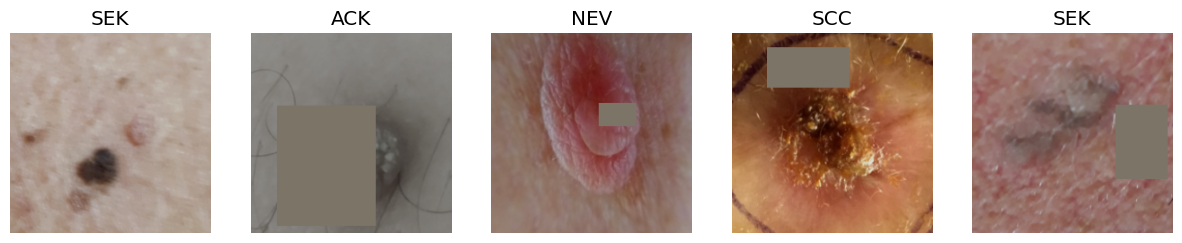

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

# Loader temporal con el pipeline de augmentation para visualizar
viz_dataset = datasets.ImageFolder(f"{RUTA_BASE}/train", transform=train_pipeline)
viz_loader = DataLoader(viz_dataset, batch_size=BATCH_SIZE, shuffle=True)
imgs, labels = next(iter(viz_loader))

def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.permute(1, 2, 0).numpy()
    return np.clip(img * std + mean, 0, 1)

plt.figure(figsize=(15, 5))
for i in range(5):
    ax = plt.subplot(1, 5, i+1)
    plt.imshow(denormalize(imgs[i]))
    plt.title(full_train_dataset.classes[labels[i]])
    plt.axis("off")
plt.show()

del viz_dataset, viz_loader

Aquí podemos observar algunos ejemplos del data augmentation de Ultralytics.

## 3. Funciones de Entrenamiento y Evaluación

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import copy
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.metrics import (
    f1_score, confusion_matrix, classification_report,
    accuracy_score, cohen_kappa_score, precision_score, recall_score
)

# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def obtener_predicciones(model, loader, device):
    """Obtiene predicciones, etiquetas reales y probabilidades de un modelo."""
    model.eval()
    y_true, y_pred, y_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())
    return np.array(y_true), np.array(y_pred), np.array(y_probs)


def calcular_metricas(y_true, y_pred):
    """Calcula todas las metricas a partir de etiquetas reales y predichas."""
    return {
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'precision_weighted': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_weighted': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'kappa': cohen_kappa_score(y_true, y_pred),
    }


def mostrar_reporte_completo(y_true, y_pred, classes, titulo):
    """Muestra matriz de confusion, classification report y todas las metricas."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Matriz de Confusion - {titulo}')
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Prediccion')
    plt.show()

    metricas = calcular_metricas(y_true, y_pred)

    print(f"\n{'='*70}")
    print(f"REPORTE: {titulo}")
    print(f"{'='*70}")
    print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))
    print(f"{'─'*70}")
    print(f"  Accuracy:           {metricas['accuracy']:.4f}")
    print(f"  F1 Macro:           {metricas['f1_macro']:.4f}")
    print(f"  F1 Weighted:        {metricas['f1_weighted']:.4f}")
    print(f"  Precision Macro:    {metricas['precision_macro']:.4f}")
    print(f"  Precision Weighted: {metricas['precision_weighted']:.4f}")
    print(f"  Recall Macro:       {metricas['recall_macro']:.4f}")
    print(f"  Recall Weighted:    {metricas['recall_weighted']:.4f}")
    print(f"  Cohen's Kappa:      {metricas['kappa']:.4f}")
    print(f"{'='*70}")

    return metricas


# ============================================================
# FUNCIONES DE VISUALIZACION
# ============================================================

def plot_training_history(historial, titulo=""):
    """Curvas de entrenamiento de un solo run."""
    epochs = range(1, len(historial['train_loss']) + 1)

    plt.figure(figsize=(15, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, historial['train_loss'], label='Train Loss', color='blue', linewidth=2)
    plt.plot(epochs, historial['val_loss'], label='Val Loss', color='orange', linestyle='--', linewidth=2)
    plt.title(f'Loss - {titulo}')
    plt.xlabel('Epocas')
    plt.ylabel('CrossEntropy Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, historial['val_f1'], label='Val F1 (Macro)', color='green', marker='o', linewidth=2)
    plt.axhline(y=max(historial['val_f1']), color='r', linestyle=':', label=f'Mejor: {max(historial["val_f1"]):.4f}')
    plt.title(f'F1-Score - {titulo}')
    plt.xlabel('Epocas')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_kfold_history(historiales, nombre_exp):
    """Curvas promediadas de K folds con banda de desviacion estandar."""
    max_epochs = max(len(h['train_loss']) for h in historiales)

    def pad(lst, length):
        return lst + [lst[-1]] * (length - len(lst))

    train_losses = np.array([pad(h['train_loss'], max_epochs) for h in historiales])
    val_losses = np.array([pad(h['val_loss'], max_epochs) for h in historiales])
    val_f1s = np.array([pad(h['val_f1'], max_epochs) for h in historiales])

    epochs = range(1, max_epochs + 1)
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Loss
    ax = axes[0]
    mean_tl, std_tl = train_losses.mean(axis=0), train_losses.std(axis=0)
    mean_vl, std_vl = val_losses.mean(axis=0), val_losses.std(axis=0)
    ax.plot(epochs, mean_tl, 'b-', linewidth=2, label='Train Loss (media)')
    ax.fill_between(epochs, mean_tl - std_tl, mean_tl + std_tl, alpha=0.2, color='blue')
    ax.plot(epochs, mean_vl, 'r--', linewidth=2, label='Val Loss (media)')
    ax.fill_between(epochs, mean_vl - std_vl, mean_vl + std_vl, alpha=0.2, color='red')
    ax.set_title(f'Loss Promedio - {nombre_exp}')
    ax.set_xlabel('Epocas')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # F1
    ax = axes[1]
    mean_f1, std_f1 = val_f1s.mean(axis=0), val_f1s.std(axis=0)
    ax.plot(epochs, mean_f1, 'g-', linewidth=2, label='Val F1 Macro (media)')
    ax.fill_between(epochs, mean_f1 - std_f1, mean_f1 + std_f1, alpha=0.2, color='green')
    ax.set_title(f'F1-Score Promedio - {nombre_exp}')
    ax.set_xlabel('Epocas')
    ax.set_ylabel('F1 Score')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# ============================================================
# FUNCION DE ENTRENAMIENTO (un fold)
# ============================================================

def entrenar_modelo(model, train_loader, val_loader, criterion, optimizer, device, epochs=25, nombre_archivo="mejor_modelo.pth"):
    """Entrena un modelo y guarda el mejor segun F1 macro en validacion."""
    historial = {'train_loss': [], 'val_loss': [], 'val_f1': []}
    best_f1 = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        # Train
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)

        # Validation
        model.eval()
        val_loss = 0.0
        y_true, y_pred = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                y_true.extend(labels.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_f1 = f1_score(y_true, y_pred, average='macro')

        historial['train_loss'].append(epoch_train_loss)
        historial['val_loss'].append(epoch_val_loss)
        historial['val_f1'].append(epoch_val_f1)

        marcador = ""
        if epoch_val_f1 > best_f1:
            best_f1 = epoch_val_f1
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), nombre_archivo)
            marcador = " ** Mejor!"

        print(f"  Ep {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.3f} | Val Loss: {epoch_val_loss:.3f} | Val F1: {epoch_val_f1:.4f}{marcador}")

    print(f"  Mejor F1 Val: {best_f1:.4f}")
    model.load_state_dict(best_model_wts)
    return model, historial


# ============================================================
# PIPELINE COMPLETO 5-FOLD CV
# ============================================================

def lanzar_experimento_kfold(crear_modelo_fn, nombre_exp, device, epochs=25):
    """
    Ejecuta el pipeline completo de 5-Fold Cross-Validation.

    Args:
        crear_modelo_fn: funcion(num_classes, device) -> (model, optimizer)
        nombre_exp: nombre del experimento
        device: torch device
        epochs: epocas por fold

    Usa variables globales: full_train_dataset, targets, skf,
        train_pipeline, val_test_pipeline, test_loader,
        BATCH_SIZE, SubsetConTransform
    """
    print(f"\n{'='*60}")
    print(f"EXPERIMENTO 5-FOLD CV: {nombre_exp}")
    print(f"{'='*60}")

    num_classes = len(full_train_dataset.classes)
    classes = full_train_dataset.classes

    metricas_folds = []
    historiales = []
    modelos_state_dicts = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(range(len(targets)), targets)):
        print(f"\n{'─'*50}")
        print(f"FOLD {fold+1}/{skf.n_splits} | Train: {len(train_idx)} | Val: {len(val_idx)}")
        print(f"{'─'*50}")

        # --- DataLoaders del fold ---
        fold_train = SubsetConTransform(full_train_dataset, train_idx, train_pipeline)
        fold_val = SubsetConTransform(full_train_dataset, val_idx, val_test_pipeline)

        fold_train_loader = DataLoader(
            fold_train, batch_size=BATCH_SIZE, shuffle=True,
            num_workers=8, pin_memory=True
        )
        fold_val_loader = DataLoader(
            fold_val, batch_size=BATCH_SIZE, shuffle=False,
            num_workers=4, pin_memory=True
        )

        # --- Pesos de clase para este fold ---
        fold_targets = [targets[i] for i in train_idx]
        class_counts = np.bincount(fold_targets, minlength=num_classes).astype(float)
        weights = 1.0 / class_counts
        weights = weights / weights.sum() * num_classes
        class_weights = torch.FloatTensor(weights).to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)

        # --- Modelo y optimizador frescos ---
        model, optimizer = crear_modelo_fn(num_classes, device)

        # --- Entrenar ---
        model, historial = entrenar_modelo(
            model, fold_train_loader, fold_val_loader,
            criterion, optimizer, device, epochs,
            nombre_archivo=f"{nombre_exp}_fold{fold+1}.pth"
        )

        # --- Metricas del fold en validacion ---
        y_true, y_pred, _ = obtener_predicciones(model, fold_val_loader, device)
        fold_metricas = calcular_metricas(y_true, y_pred)

        print(f"  >> Fold {fold+1} Val: F1={fold_metricas['f1_macro']:.4f} | "
              f"Acc={fold_metricas['accuracy']:.4f} | Kappa={fold_metricas['kappa']:.4f}")

        metricas_folds.append(fold_metricas)
        historiales.append(historial)
        modelos_state_dicts.append(copy.deepcopy(model.state_dict()))

    # ============================================================
    # RESUMEN CROSS-VALIDATION
    # ============================================================
    print(f"\n{'='*60}")
    print(f"RESUMEN 5-FOLD CV: {nombre_exp}")
    print(f"{'='*60}")

    metric_names = ['f1_macro', 'f1_weighted', 'accuracy',
                    'precision_macro', 'precision_weighted',
                    'recall_macro', 'recall_weighted', 'kappa']

    tabla = {}
    for metric in metric_names:
        valores = [m[metric] for m in metricas_folds]
        tabla[metric] = [round(v, 4) for v in valores] + [round(np.mean(valores), 4), round(np.std(valores), 4)]

    cols = [f"Fold {i+1}" for i in range(skf.n_splits)] + ["Media", "Std"]
    df_resumen = pd.DataFrame(tabla, index=cols).T
    print(df_resumen.to_string())

    # --- Curvas promediadas ---
    print(f"\nCurvas de entrenamiento promediadas:")
    plot_kfold_history(historiales, nombre_exp)

    # --- Curvas individuales por fold ---
    for i, h in enumerate(historiales):
        plot_training_history(h, titulo=f"{nombre_exp} - Fold {i+1}")

    # ============================================================
    # EVALUACION EN TEST: MEJOR MODELO (fold con mejor F1 val)
    # ============================================================
    f1_scores = [m['f1_macro'] for m in metricas_folds]
    best_fold = int(np.argmax(f1_scores))

    print(f"\nMejor fold: {best_fold+1} (F1 Macro Val = {f1_scores[best_fold]:.4f})")

    print(f"\n{'='*60}")
    print(f"TEST - MEJOR MODELO (Fold {best_fold+1}) - {nombre_exp}")
    print(f"{'='*60}")

    model_best, _ = crear_modelo_fn(num_classes, device)
    model_best.load_state_dict(modelos_state_dicts[best_fold])

    y_true_test, y_pred_test, _ = obtener_predicciones(model_best, test_loader, device)
    metricas_test_best = mostrar_reporte_completo(
        y_true_test, y_pred_test, classes,
        f"TEST - Mejor Modelo (Fold {best_fold+1}) - {nombre_exp}"
    )

    # ============================================================
    # EVALUACION EN TEST: ENSEMBLE DE FOLDS (media de probabilidades)
    # ============================================================
    print(f"\n{'='*60}")
    print(f"TEST - ENSEMBLE {skf.n_splits} FOLDS - {nombre_exp}")
    print(f"{'='*60}")

    all_probs = []
    for i, state_dict in enumerate(modelos_state_dicts):
        model_i, _ = crear_modelo_fn(num_classes, device)
        model_i.load_state_dict(state_dict)
        _, _, probs_i = obtener_predicciones(model_i, test_loader, device)
        all_probs.append(probs_i)

    mean_probs = np.mean(all_probs, axis=0)
    y_pred_ensemble = np.argmax(mean_probs, axis=1)

    metricas_test_ensemble = mostrar_reporte_completo(
        y_true_test, y_pred_ensemble, classes,
        f"TEST - Ensemble {skf.n_splits} Folds - {nombre_exp}"
    )

    # ============================================================
    # COMPARATIVA FINAL: MEJOR MODELO vs ENSEMBLE
    # ============================================================
    print(f"\n{'='*60}")
    print(f"COMPARATIVA TEST: Mejor Fold vs Ensemble - {nombre_exp}")
    print(f"{'='*60}")

    comp = pd.DataFrame({
        f'Mejor (Fold {best_fold+1})': metricas_test_best,
        f'Ensemble ({skf.n_splits} Folds)': metricas_test_ensemble
    }).T
    print(comp.round(4).to_string())
    print(f"{'='*60}")

    return {
        'metricas_folds': metricas_folds,
        'historiales': historiales,
        'modelos_state_dicts': modelos_state_dicts,
        'best_fold': best_fold,
        'metricas_test_best': metricas_test_best,
        'metricas_test_ensemble': metricas_test_ensemble,
        'df_resumen': df_resumen,
    }


print("Funciones cargadas.")

Funciones cargadas.


## 4. Modelo 1: ResNet-18

ResNet utiliza conexiones residuales (skip connections) que permiten entrenar redes profundas sin degradación del gradiente.

Usando device: cuda

EXPERIMENTO 5-FOLD CV: ResNet18_5Fold

──────────────────────────────────────────────────
FOLD 1/5 | Train: 519 | Val: 130
──────────────────────────────────────────────────
  Ep 1/25 | Train Loss: 1.648 | Val Loss: 1.304 | Val F1: 0.4593 ** Mejor!
  Ep 2/25 | Train Loss: 1.264 | Val Loss: 1.192 | Val F1: 0.4536
  Ep 3/25 | Train Loss: 1.144 | Val Loss: 1.204 | Val F1: 0.4860 ** Mejor!
  Ep 4/25 | Train Loss: 1.075 | Val Loss: 1.177 | Val F1: 0.5065 ** Mejor!
  Ep 5/25 | Train Loss: 0.991 | Val Loss: 1.114 | Val F1: 0.5286 ** Mejor!
  Ep 6/25 | Train Loss: 0.958 | Val Loss: 1.205 | Val F1: 0.5511 ** Mejor!
  Ep 7/25 | Train Loss: 0.861 | Val Loss: 1.210 | Val F1: 0.5706 ** Mejor!
  Ep 8/25 | Train Loss: 0.796 | Val Loss: 1.196 | Val F1: 0.5753 ** Mejor!
  Ep 9/25 | Train Loss: 0.772 | Val Loss: 1.191 | Val F1: 0.5785 ** Mejor!
  Ep 10/25 | Train Loss: 0.675 | Val Loss: 1.285 | Val F1: 0.5770
  Ep 11/25 | Train Loss: 0.656 | Val Loss: 1.262 | Val F1: 0.6181 ** Mejor

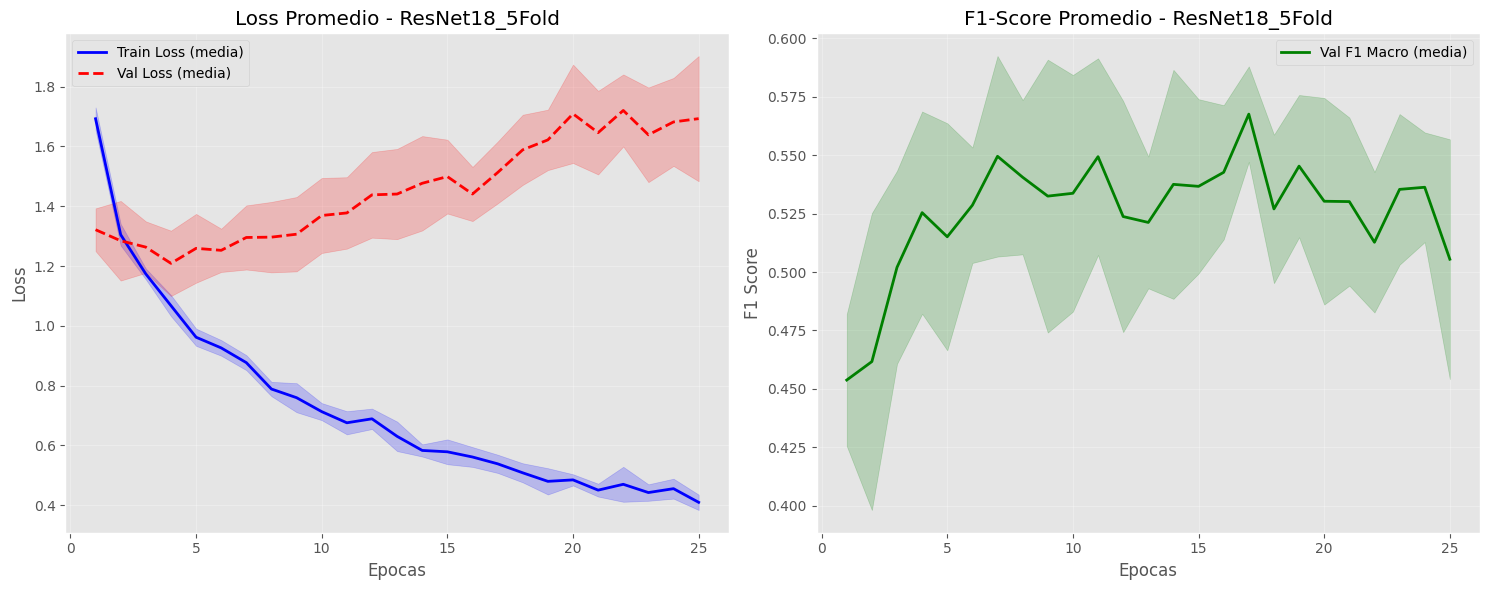

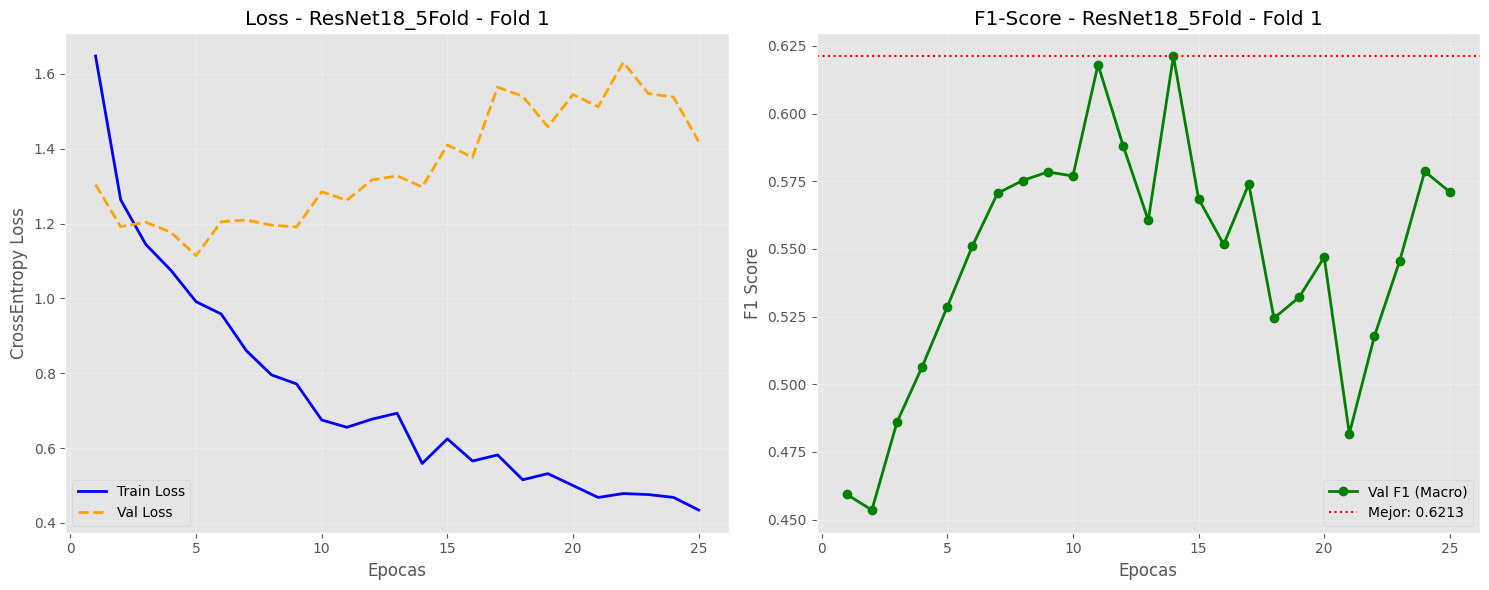

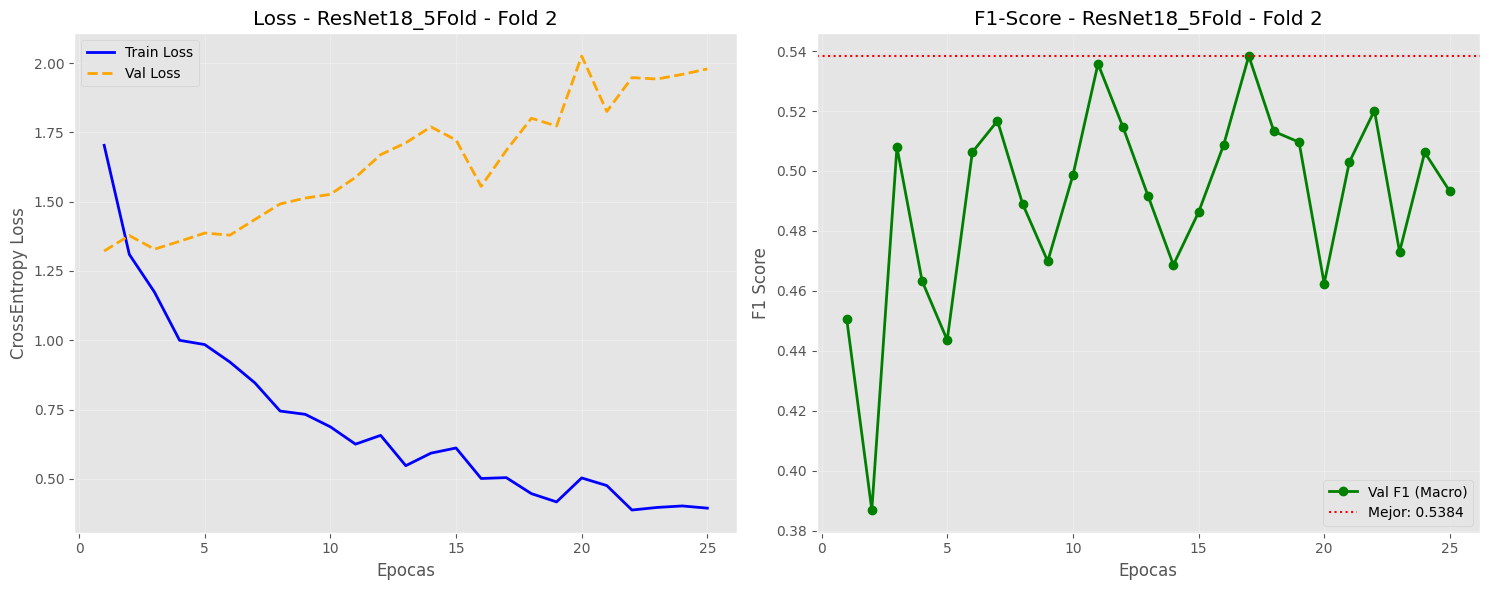

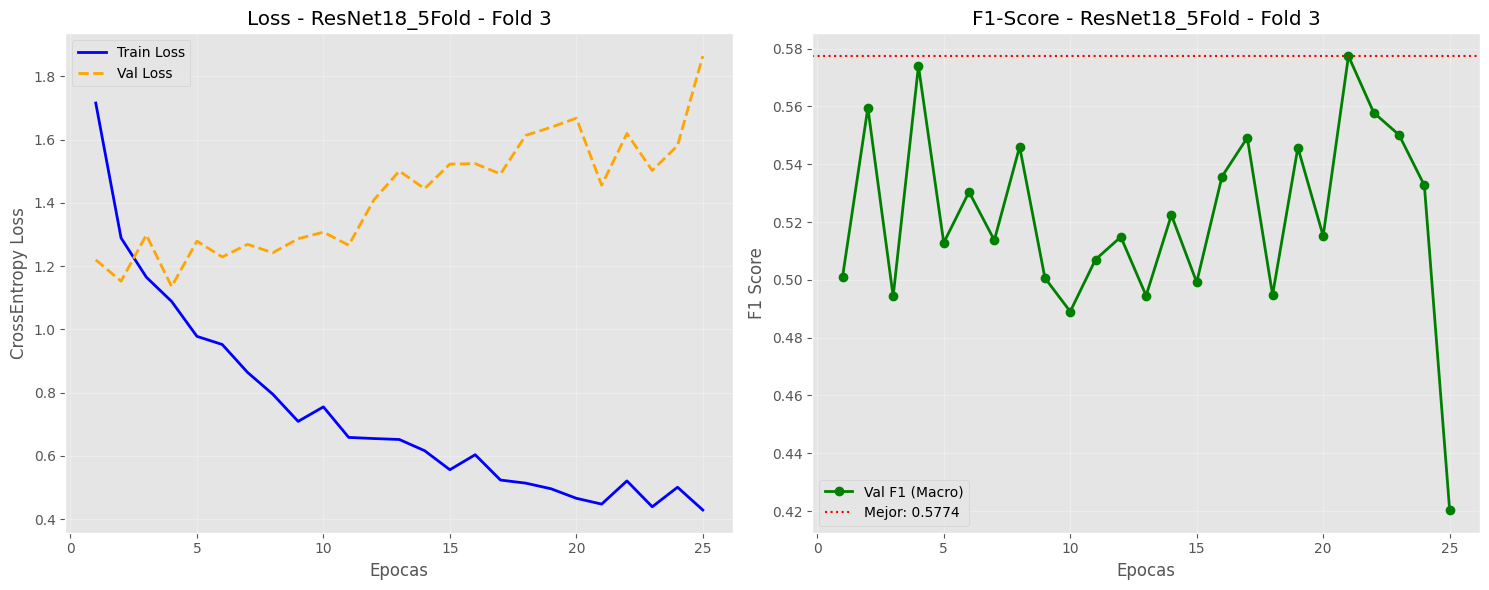

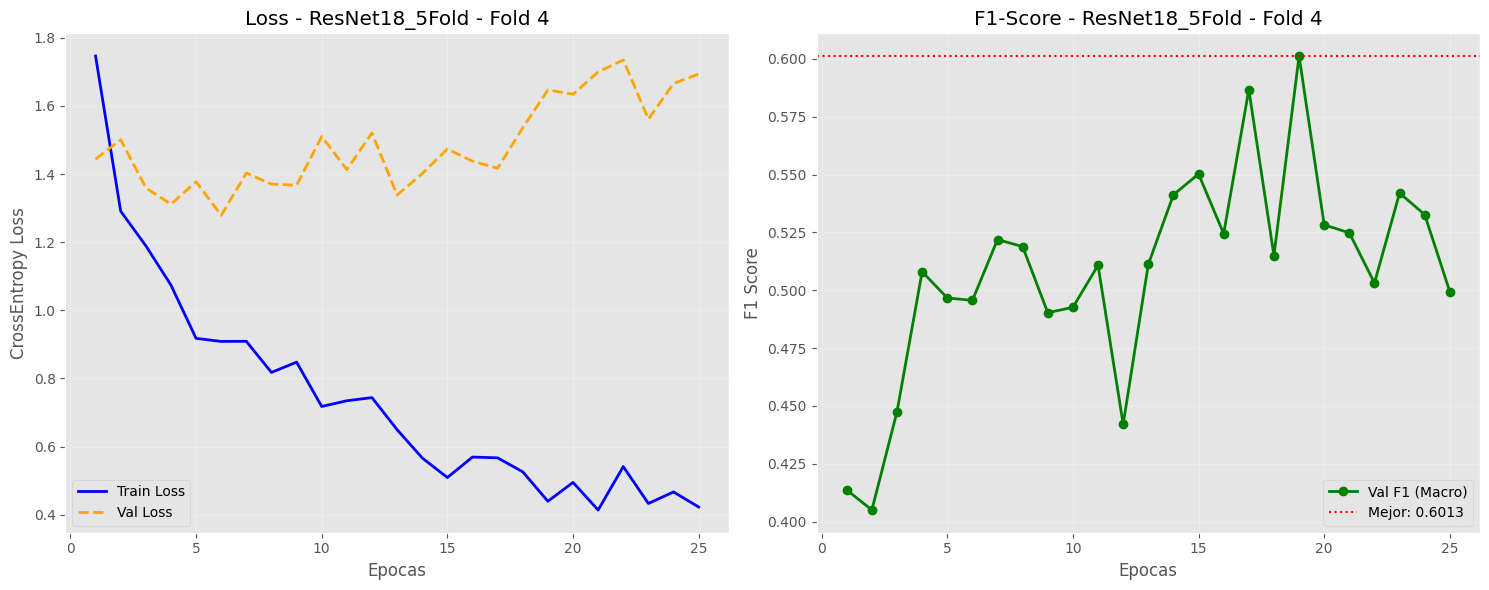

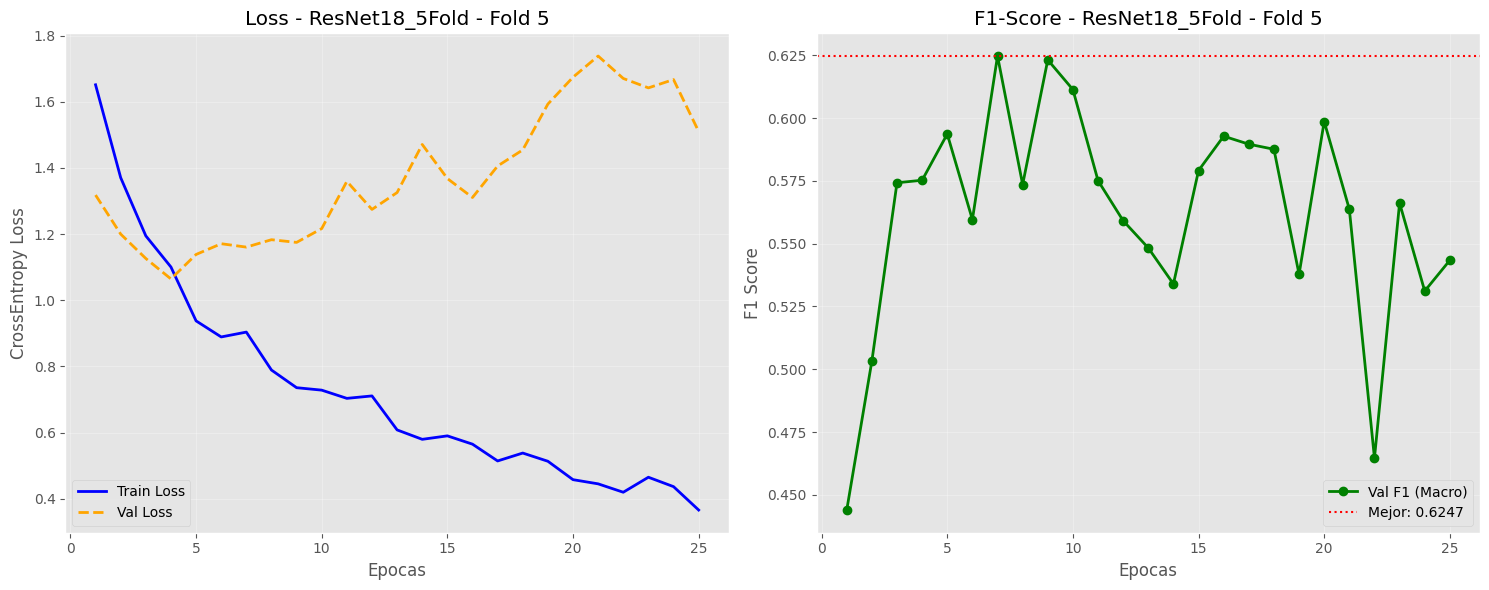


Mejor fold: 5 (F1 Macro Val = 0.6247)

TEST - MEJOR MODELO (Fold 5) - ResNet18_5Fold


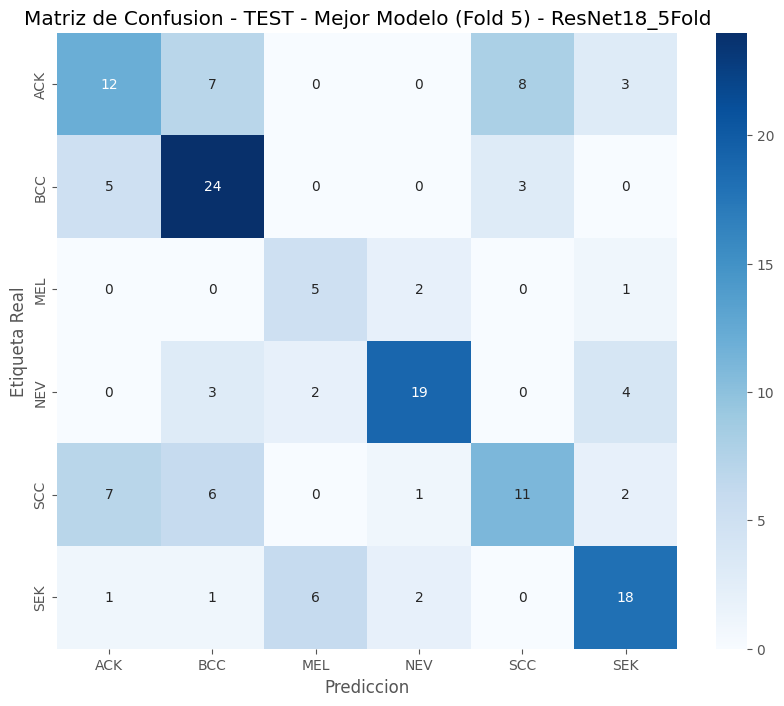


REPORTE: TEST - Mejor Modelo (Fold 5) - ResNet18_5Fold
              precision    recall  f1-score   support

         ACK       0.48      0.40      0.44        30
         BCC       0.59      0.75      0.66        32
         MEL       0.38      0.62      0.48         8
         NEV       0.79      0.68      0.73        28
         SCC       0.50      0.41      0.45        27
         SEK       0.64      0.64      0.64        28

    accuracy                           0.58       153
   macro avg       0.56      0.58      0.57       153
weighted avg       0.59      0.58      0.58       153

──────────────────────────────────────────────────────────────────────
  Accuracy:           0.5817
  F1 Macro:           0.5654
  F1 Weighted:        0.5786
  Precision Macro:    0.5641
  Precision Weighted: 0.5874
  Recall Macro:       0.5840
  Recall Weighted:    0.5817
  Cohen's Kappa:      0.4898

TEST - ENSEMBLE 5 FOLDS - ResNet18_5Fold


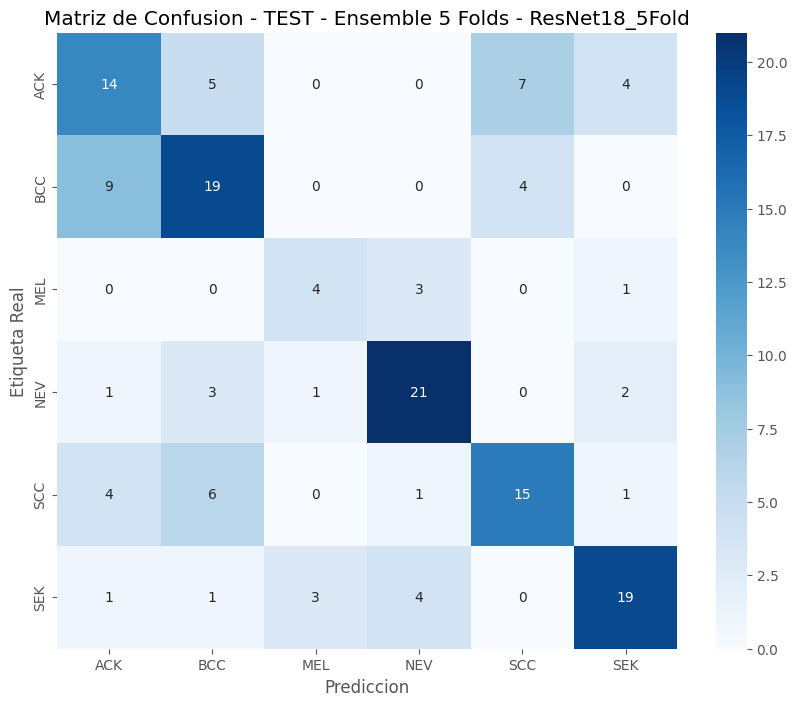


REPORTE: TEST - Ensemble 5 Folds - ResNet18_5Fold
              precision    recall  f1-score   support

         ACK       0.48      0.47      0.47        30
         BCC       0.56      0.59      0.58        32
         MEL       0.50      0.50      0.50         8
         NEV       0.72      0.75      0.74        28
         SCC       0.58      0.56      0.57        27
         SEK       0.70      0.68      0.69        28

    accuracy                           0.60       153
   macro avg       0.59      0.59      0.59       153
weighted avg       0.60      0.60      0.60       153

──────────────────────────────────────────────────────────────────────
  Accuracy:           0.6013
  F1 Macro:           0.5907
  F1 Weighted:        0.6008
  Precision Macro:    0.5911
  Precision Weighted: 0.6008
  Recall Macro:       0.5908
  Recall Weighted:    0.6013
  Cohen's Kappa:      0.5118

COMPARATIVA TEST: Mejor Fold vs Ensemble - ResNet18_5Fold
                    f1_macro  f1_weighted  a

In [26]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)


def crear_resnet18(num_classes, device):
    
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    num_ftrs = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_ftrs, num_classes)
        )
    model = model.to(device)

    optimizer = optim.AdamW([
        {'params': model.layer4.parameters(), 'lr': 0.000131},
        {'params': model.fc.parameters(), 'lr': 0.000437}
    ], weight_decay=0.02365)

    return model, optimizer


resultados_resnet = lanzar_experimento_kfold(
    crear_modelo_fn=crear_resnet18,
    nombre_exp="ResNet18_5Fold",
    device=device,
    epochs=25
)

## 6. Modelo 3: DenseNet-121

DenseNet conecta cada capa con todas las anteriores mediante conexiones densas, reutilizando features de forma eficiente.

Usando device: cuda

EXPERIMENTO 5-FOLD CV: DenseNet121_5Fold

──────────────────────────────────────────────────
FOLD 1/5 | Train: 519 | Val: 130
──────────────────────────────────────────────────
  Ep 1/25 | Train Loss: 1.573 | Val Loss: 1.275 | Val F1: 0.4915 ** Mejor!
  Ep 2/25 | Train Loss: 1.258 | Val Loss: 1.208 | Val F1: 0.5427 ** Mejor!
  Ep 3/25 | Train Loss: 1.093 | Val Loss: 1.152 | Val F1: 0.5674 ** Mejor!
  Ep 4/25 | Train Loss: 1.006 | Val Loss: 1.300 | Val F1: 0.4625
  Ep 5/25 | Train Loss: 0.909 | Val Loss: 1.244 | Val F1: 0.5880 ** Mejor!
  Ep 6/25 | Train Loss: 0.818 | Val Loss: 1.228 | Val F1: 0.5307
  Ep 7/25 | Train Loss: 0.771 | Val Loss: 1.220 | Val F1: 0.5105
  Ep 8/25 | Train Loss: 0.704 | Val Loss: 1.213 | Val F1: 0.5531
  Ep 9/25 | Train Loss: 0.744 | Val Loss: 1.319 | Val F1: 0.5647
  Ep 10/25 | Train Loss: 0.701 | Val Loss: 1.468 | Val F1: 0.4839
  Ep 11/25 | Train Loss: 0.607 | Val Loss: 1.470 | Val F1: 0.4623
  Ep 12/25 | Train Loss: 0.622 | Val Loss: 1.

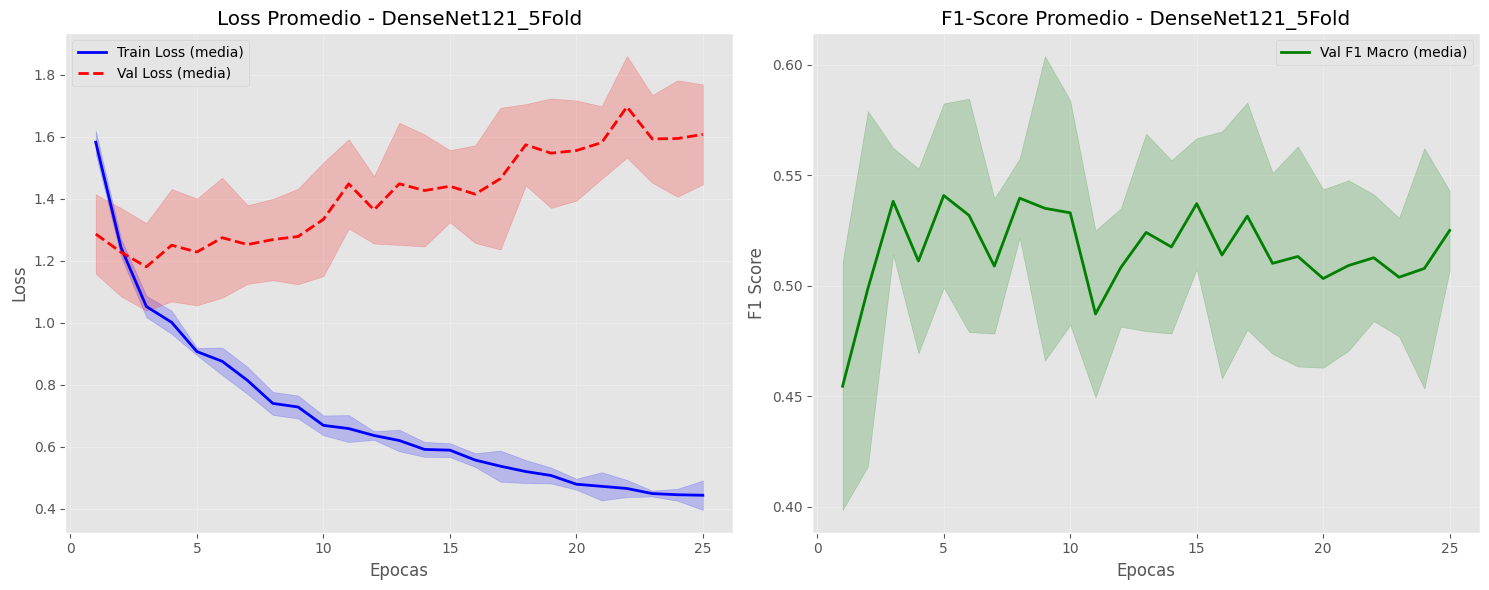

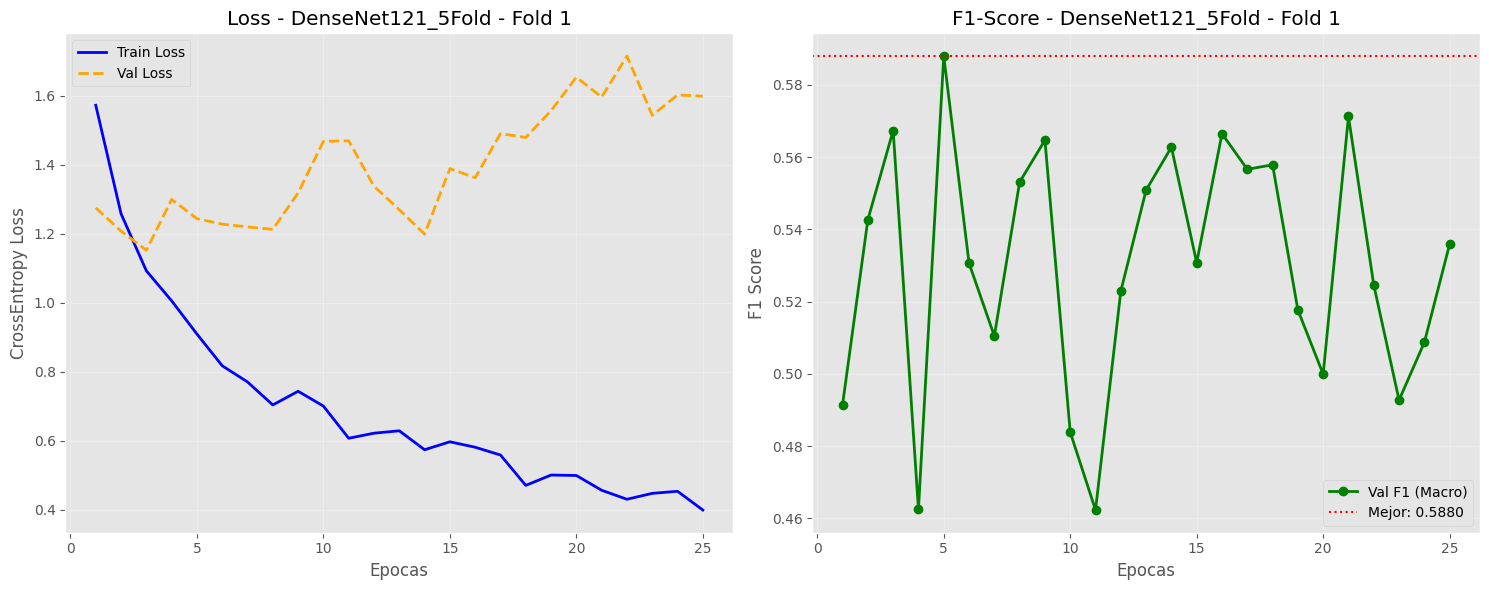

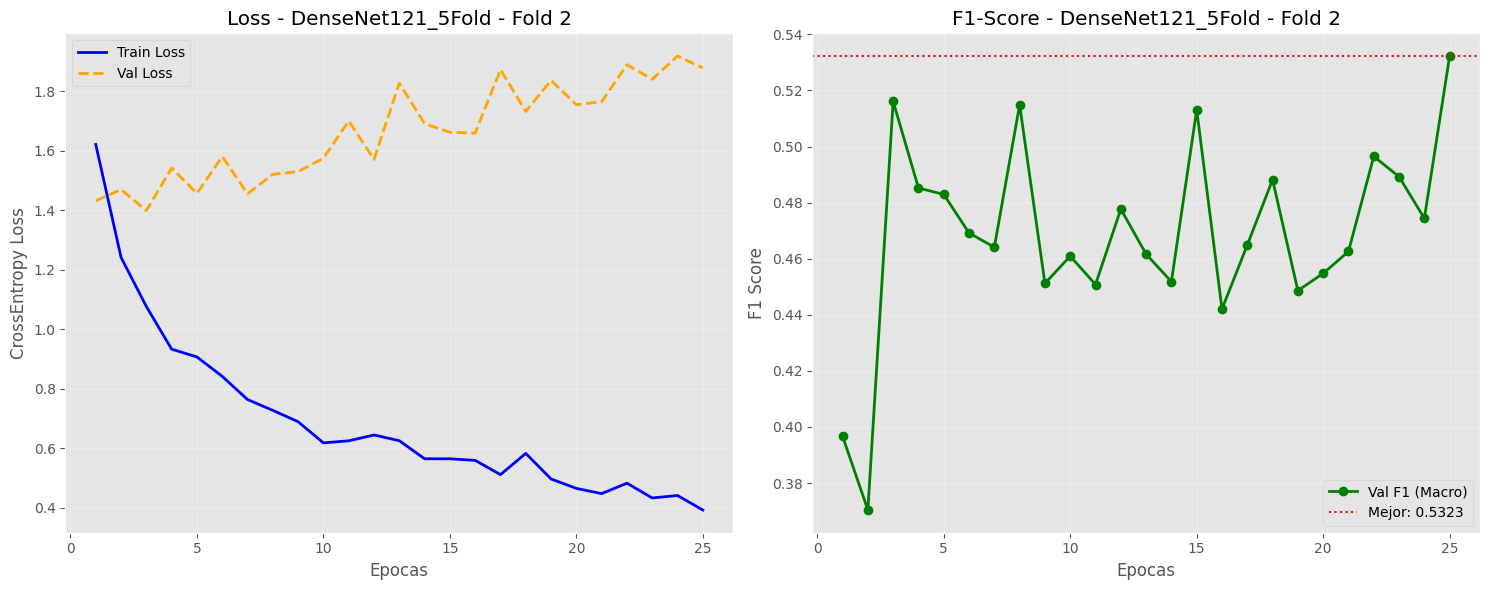

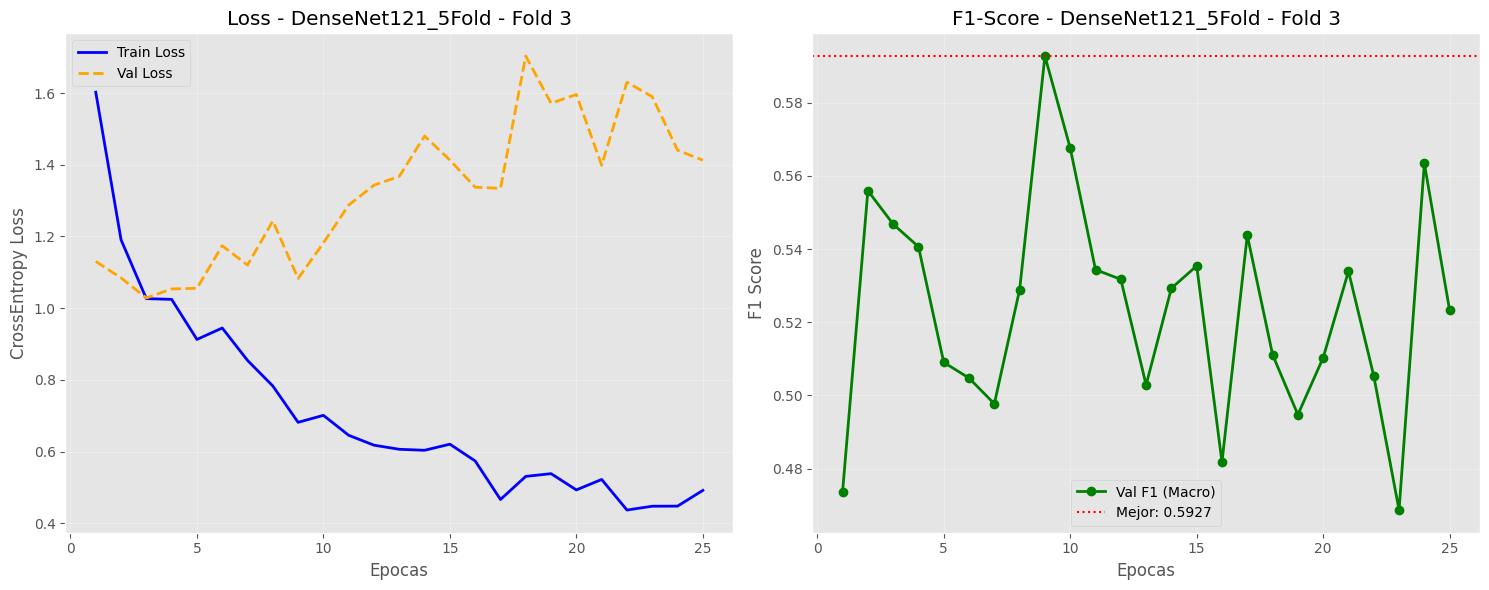

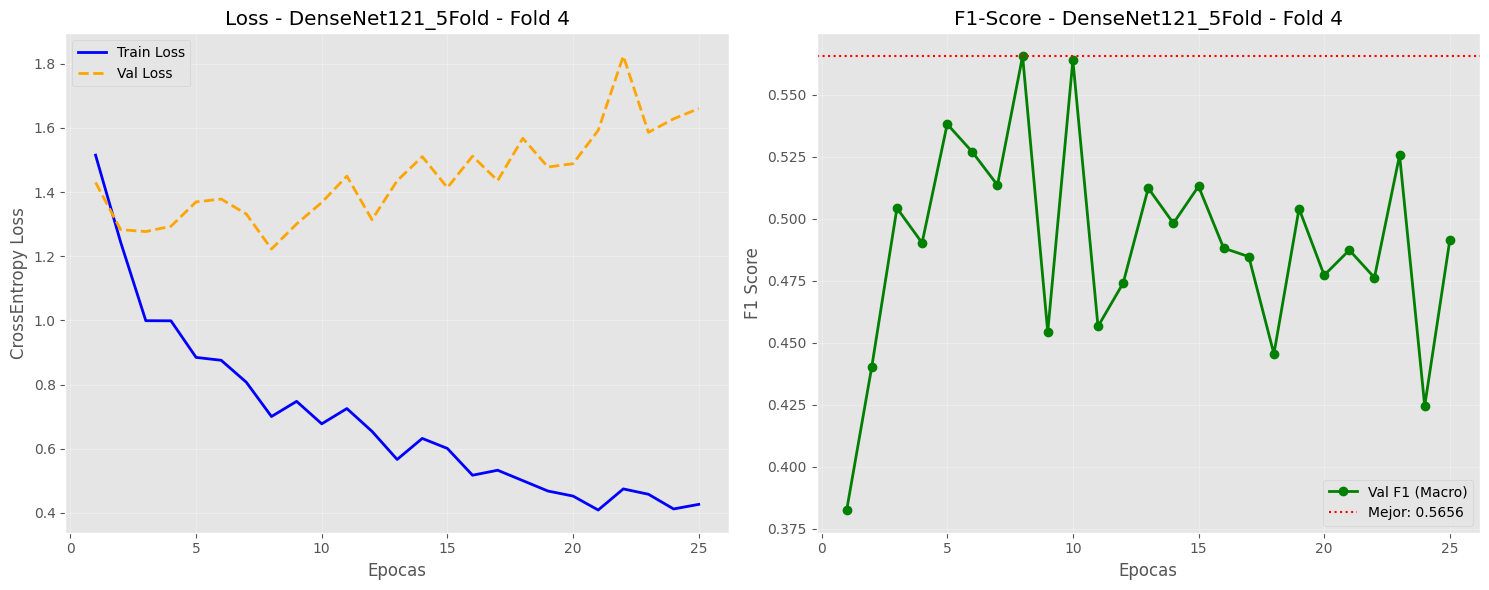

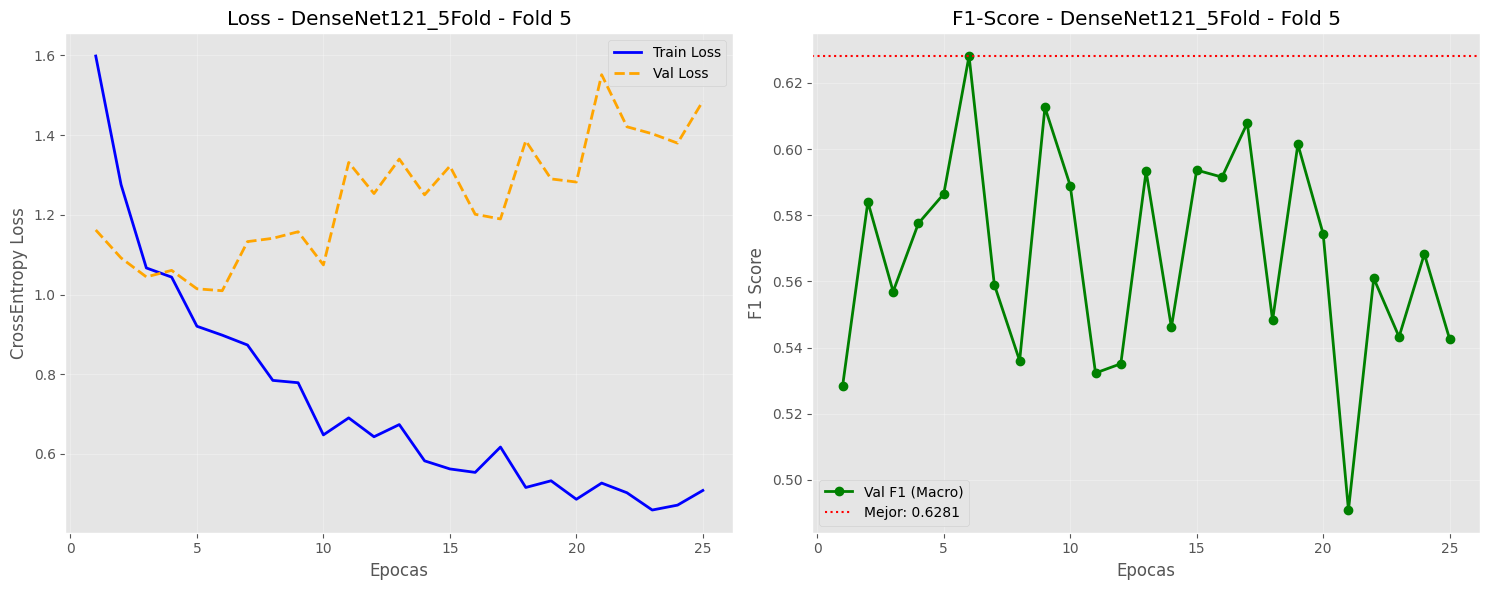


Mejor fold: 5 (F1 Macro Val = 0.6281)

TEST - MEJOR MODELO (Fold 5) - DenseNet121_5Fold


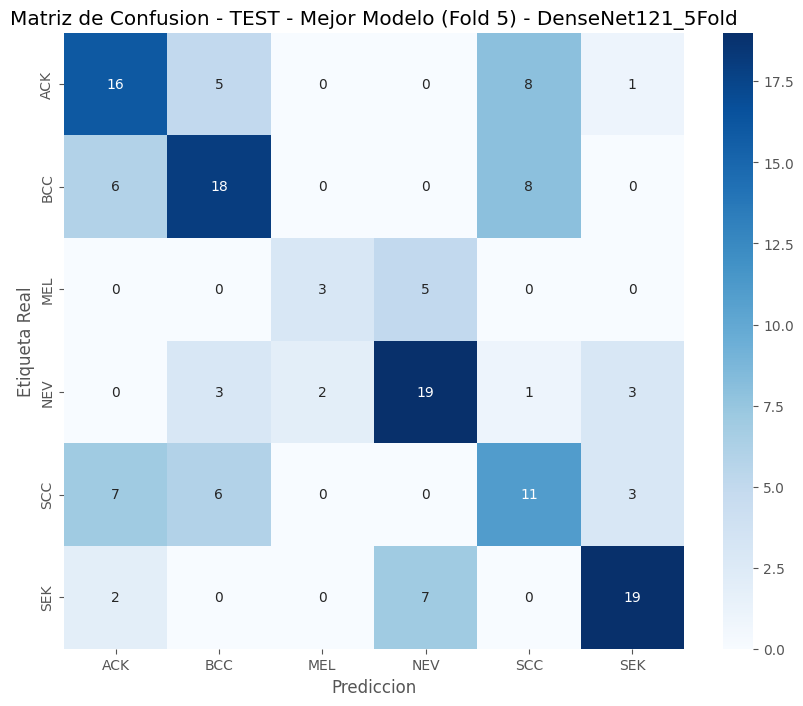


REPORTE: TEST - Mejor Modelo (Fold 5) - DenseNet121_5Fold
              precision    recall  f1-score   support

         ACK       0.52      0.53      0.52        30
         BCC       0.56      0.56      0.56        32
         MEL       0.60      0.38      0.46         8
         NEV       0.61      0.68      0.64        28
         SCC       0.39      0.41      0.40        27
         SEK       0.73      0.68      0.70        28

    accuracy                           0.56       153
   macro avg       0.57      0.54      0.55       153
weighted avg       0.57      0.56      0.56       153

──────────────────────────────────────────────────────────────────────
  Accuracy:           0.5621
  F1 Macro:           0.5494
  F1 Weighted:        0.5619
  Precision Macro:    0.5692
  Precision Weighted: 0.5654
  Recall Macro:       0.5392
  Recall Weighted:    0.5621
  Cohen's Kappa:      0.4623

TEST - ENSEMBLE 5 FOLDS - DenseNet121_5Fold


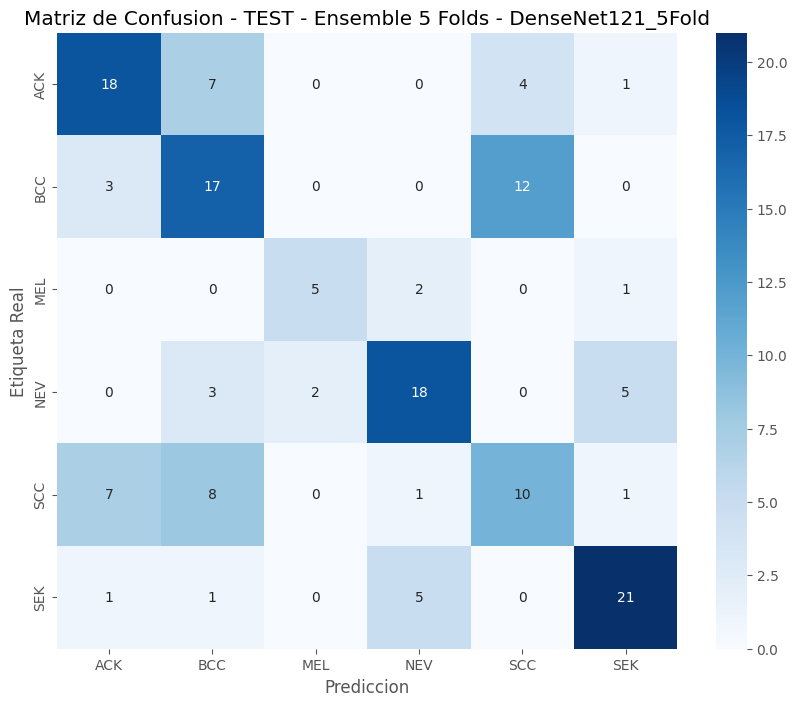


REPORTE: TEST - Ensemble 5 Folds - DenseNet121_5Fold
              precision    recall  f1-score   support

         ACK       0.62      0.60      0.61        30
         BCC       0.47      0.53      0.50        32
         MEL       0.71      0.62      0.67         8
         NEV       0.69      0.64      0.67        28
         SCC       0.38      0.37      0.38        27
         SEK       0.72      0.75      0.74        28

    accuracy                           0.58       153
   macro avg       0.60      0.59      0.59       153
weighted avg       0.58      0.58      0.58       153

──────────────────────────────────────────────────────────────────────
  Accuracy:           0.5817
  F1 Macro:           0.5930
  F1 Weighted:        0.5825
  Precision Macro:    0.6014
  Precision Weighted: 0.5849
  Recall Macro:       0.5866
  Recall Weighted:    0.5817
  Cohen's Kappa:      0.4870

COMPARATIVA TEST: Mejor Fold vs Ensemble - DenseNet121_5Fold
                    f1_macro  f1_weigh

In [27]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)


def crear_densenet121(num_classes, device):
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features.denseblock4.parameters():
        param.requires_grad = True
    for param in model.features.norm5.parameters():
        param.requires_grad = True

    num_ftrs = model.classifier.in_features

    model.classifier = nn.Sequential(  
        nn.Dropout(0.4),
        nn.Linear(num_ftrs, num_classes)
        )
    
    model = model.to(device)
    optimizer = optim.AdamW([
        {'params': model.features.denseblock4.parameters(), 'lr': 0.000960},
        {'params': model.features.norm5.parameters(), 'lr': 0.000960},
        {'params': model.classifier.parameters(), 'lr': 0.000218}
    ], weight_decay=0.000089)
    return model, optimizer


resultados_densenet = lanzar_experimento_kfold(
    crear_modelo_fn=crear_densenet121,
    nombre_exp="DenseNet121_5Fold",
    device=device,
    epochs=25
)

## 8. Modelo 5: YOLO26x-cls

YOLO con backbone potente, estado del arte en extracción de features.

In [4]:
import os
import shutil

# Ruta donde se crearan las carpetas de cada fold
FOLDS_DIR = os.path.abspath(os.path.join(RUTA_BASE, "folds"))
classes = full_train_dataset.classes

# Limpiar folds anteriores si existen
if os.path.exists(FOLDS_DIR):
    shutil.rmtree(FOLDS_DIR)

for fold, (train_idx, val_idx) in enumerate(skf.split(range(len(targets)), targets)):
    fold_name = f"fold_{fold+1}"

    # Crear carpetas train/val por clase
    for split_name in ["train", "val"]:
        for class_name in classes:
            os.makedirs(os.path.join(FOLDS_DIR, fold_name, split_name, class_name), exist_ok=True)

    # Symlinks para train del fold
    for idx in train_idx:
        src = os.path.abspath(full_train_dataset.samples[idx][0])
        cls = classes[full_train_dataset.targets[idx]]
        dst = os.path.join(FOLDS_DIR, fold_name, "train", cls, os.path.basename(src))
        os.symlink(src, dst)

    # Symlinks para val del fold
    for idx in val_idx:
        src = os.path.abspath(full_train_dataset.samples[idx][0])
        cls = classes[full_train_dataset.targets[idx]]
        dst = os.path.join(FOLDS_DIR, fold_name, "val", cls, os.path.basename(src))
        os.symlink(src, dst)

    print(f"Fold {fold+1}: train={len(train_idx)} imgs, val={len(val_idx)} imgs")

print(f"\nEstructura creada en: {FOLDS_DIR}")

# Verificar conteos
for fold in range(1, K_FOLDS + 1):
    print(f"\n--- Fold {fold} ---")
    for split_name in ["train", "val"]:
        total = 0
        for class_name in classes:
            path = os.path.join(FOLDS_DIR, f"fold_{fold}", split_name, class_name)
            n = len(os.listdir(path))
            total += n
        print(f"  {split_name}: {total} imgs")

Fold 1: train=519 imgs, val=130 imgs
Fold 2: train=519 imgs, val=130 imgs
Fold 3: train=519 imgs, val=130 imgs
Fold 4: train=519 imgs, val=130 imgs
Fold 5: train=520 imgs, val=129 imgs

Estructura creada en: /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_MULTICLASE/folds

--- Fold 1 ---
  train: 519 imgs
  val: 130 imgs

--- Fold 2 ---
  train: 519 imgs
  val: 130 imgs

--- Fold 3 ---
  train: 519 imgs
  val: 130 imgs

--- Fold 4 ---
  train: 519 imgs
  val: 130 imgs

--- Fold 5 ---
  train: 520 imgs
  val: 129 imgs


In [6]:
from ultralytics import YOLO
import torch
import gc

mejores_pesos_yolo = []

# Hiperparámetros óptimos encontrados por Optuna
BEST_PARAMS = {
    'lr0': 0.009336,
    'lrf': 0.036616,
    'momentum': 0.893299,
    'weight_decay': 0.000569,
    'warmup_epochs': 4,
    'dropout': 0.4,
    'batch': 16,
    'optimizer': 'SGD'
}

for fold in range(1, K_FOLDS + 1):
    fold_path = os.path.abspath(os.path.join(FOLDS_DIR, f"fold_{fold}"))

    print(f"\n{'='*50}")
    print(f"YOLO26x - FOLD {fold}/{K_FOLDS}")
    print(f"Data: {fold_path}")
    print(f"{'='*50}")

    model = YOLO('yolo26x-cls.pt')

    results = model.train(
        data=fold_path,
        epochs=25,
        imgsz=224,
        batch=BEST_PARAMS['batch'],
        patience=5,
        project='runs',
        name=f'YOLO26x_Fold{fold}',
        # Hiperparámetros óptimos de Optuna
        lr0=BEST_PARAMS['lr0'],
        lrf=BEST_PARAMS['lrf'],
        momentum=BEST_PARAMS['momentum'],
        weight_decay=BEST_PARAMS['weight_decay'],
        warmup_epochs=BEST_PARAMS['warmup_epochs'],
        dropout=BEST_PARAMS['dropout'],
        optimizer=BEST_PARAMS['optimizer']
    )

    # Guardar ruta del mejor modelo de este fold
    best_pt = f"runs/YOLO26x_Fold{fold}/weights/best.pt"
    mejores_pesos_yolo.append(best_pt)
    print(f"✅ Fold {fold} completado. Pesos: {best_pt}")
    
    # ⚠️ CRÍTICO: Liberar memoria entre folds
    del model
    del results
    
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    
    gc.collect()
    print(f"🧹 Memoria liberada después del fold {fold}")

print(f"\n{'='*50}")
print("✅ 5-Fold YOLO completado.")
print(f"{'='*50}")
for i, p in enumerate(mejores_pesos_yolo):
    print(f"  Fold {i+1}: {p}")


YOLO26x - FOLD 1/5
Data: /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_MULTICLASE/folds/fold_1
New https://pypi.org/project/ultralytics/8.4.9 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.7 🚀 Python-3.11.14 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_MULTICLASE/folds/fold_1, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.4, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half

### Evaluación de YOLO26x

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt


EVALUACION 5-FOLD CV: YOLO26x_5Fold

──────────────────────────────────────────────────
FOLD 1/5
──────────────────────────────────────────────────
  >> Fold 1 Val: F1=0.5861 | Acc=0.6077 | Kappa=0.5199

──────────────────────────────────────────────────
FOLD 2/5
──────────────────────────────────────────────────
  >> Fold 2 Val: F1=0.5001 | Acc=0.5231 | Kappa=0.4188

──────────────────────────────────────────────────
FOLD 3/5
──────────────────────────────────────────────────
  >> Fold 3 Val: F1=0.6263 | Acc=0.6692 | Kappa=0.5936

──────────────────────────────────────────────────
FOLD 4/5
──────────────────────────────────────────────────
  >> Fold 4 Val: F1=0.5850 | Acc=0.5769 | Kappa=0.4827

──────────────────────────────────────────────────
FOLD 5/5
──────────────────────────────────────────────────
  >> Fold 5 Val: F1=0.6381 | Acc=0.6434 | Kappa=0.5664

RESUMEN 5-FOLD CV: YOLO26x_5Fold
                    Fold 1  Fold 2  Fold 3  Fold 4  Fold 5   Media     Std
f1_macro           

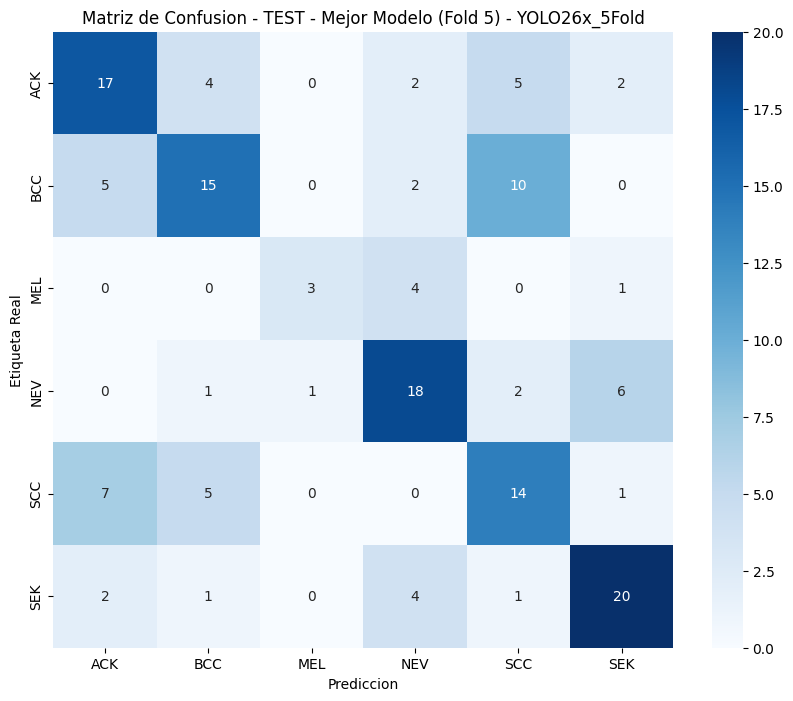


REPORTE: TEST - Mejor Modelo (Fold 5) - YOLO26x_5Fold
              precision    recall  f1-score   support

         ACK       0.55      0.57      0.56        30
         BCC       0.58      0.47      0.52        32
         MEL       0.75      0.38      0.50         8
         NEV       0.60      0.64      0.62        28
         SCC       0.44      0.52      0.47        27
         SEK       0.67      0.71      0.69        28

    accuracy                           0.57       153
   macro avg       0.60      0.55      0.56       153
weighted avg       0.58      0.57      0.57       153

──────────────────────────────────────────────────────────────────────
  Accuracy:           0.5686
  F1 Macro:           0.5599
  F1 Weighted:        0.5672
  Precision Macro:    0.5966
  Precision Weighted: 0.5764
  Recall Macro:       0.5477
  Recall Weighted:    0.5686
  Cohen's Kappa:      0.4705

TEST - ENSEMBLE 5 FOLDS - YOLO26x_5Fold


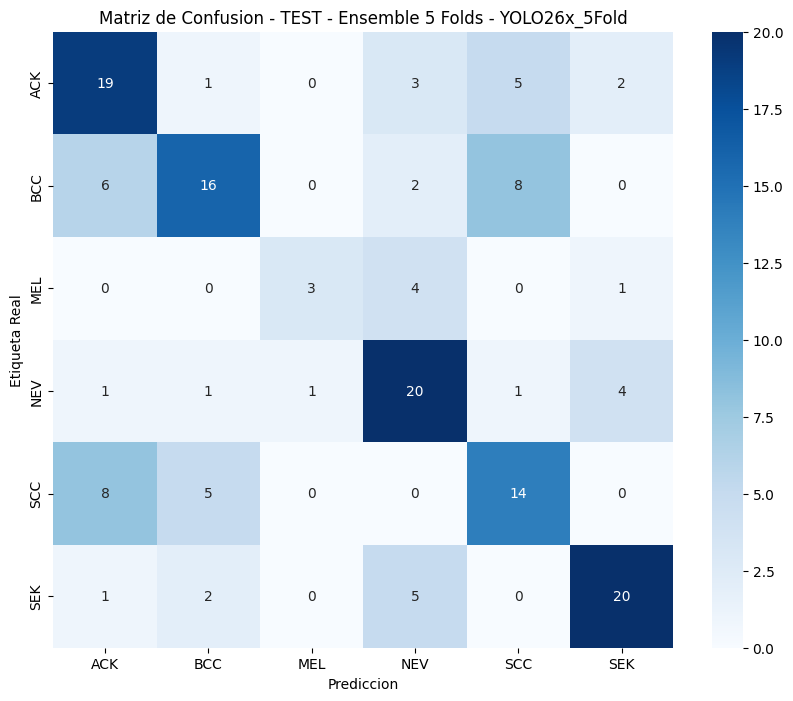


REPORTE: TEST - Ensemble 5 Folds - YOLO26x_5Fold
              precision    recall  f1-score   support

         ACK       0.54      0.63      0.58        30
         BCC       0.64      0.50      0.56        32
         MEL       0.75      0.38      0.50         8
         NEV       0.59      0.71      0.65        28
         SCC       0.50      0.52      0.51        27
         SEK       0.74      0.71      0.73        28

    accuracy                           0.60       153
   macro avg       0.63      0.58      0.59       153
weighted avg       0.61      0.60      0.60       153

──────────────────────────────────────────────────────────────────────
  Accuracy:           0.6013
  F1 Macro:           0.5879
  F1 Weighted:        0.5992
  Precision Macro:    0.6270
  Precision Weighted: 0.6110
  Recall Macro:       0.5759
  Recall Weighted:    0.6013
  Cohen's Kappa:      0.5104

COMPARATIVA TEST: Mejor Fold vs Ensemble - YOLO26x_5Fold
                    f1_macro  f1_weighted  acc

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from sklearn.metrics import (
    f1_score, confusion_matrix, classification_report,
    accuracy_score, cohen_kappa_score, precision_score, recall_score
)

# ============================================================
# FUNCION: obtener predicciones de un modelo YOLO sobre una carpeta
# ============================================================

def obtener_predicciones_yolo(model, carpeta, classes):
    """Evalua un modelo YOLO imagen por imagen sobre una carpeta con subcarpetas por clase.
    
    Returns: y_true, y_pred, y_probs (arrays numpy alineados con el orden de 'classes')
    """
    name_to_idx = {c: i for i, c in enumerate(classes)}
    y_true, y_pred, y_probs = [], [], []

    for cls_name in classes:
        cls_path = os.path.join(carpeta, cls_name)
        if not os.path.isdir(cls_path):
            continue
        true_idx = name_to_idx[cls_name]

        files = sorted([f for f in os.listdir(cls_path)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        for file in files:
            img_path = os.path.join(cls_path, file)
            results = model(img_path, verbose=False)

            # Alinear probabilidades YOLO con nuestro orden de clases
            probs = np.zeros(len(classes))
            raw_probs = results[0].probs.data.cpu().numpy()
            for yolo_idx, conf in enumerate(raw_probs):
                yolo_name = results[0].names[yolo_idx]
                if yolo_name in name_to_idx:
                    probs[name_to_idx[yolo_name]] = conf

            y_true.append(true_idx)
            y_pred.append(np.argmax(probs))
            y_probs.append(probs)

    return np.array(y_true), np.array(y_pred), np.array(y_probs)


# ============================================================
# EVALUACION 5-FOLD YOLO (equivalente a lanzar_experimento_kfold)
# ============================================================

nombre_exp = "YOLO26x_5Fold"
classes = full_train_dataset.classes
RUTA_TEST = os.path.abspath(os.path.join(RUTA_BASE, "test"))

# Rutas reales de los pesos (YOLO guarda en runs/classify/runs/)
pesos_yolo = [f"runs/classify/runs/YOLO26x_Fold{f}/weights/best.pt" for f in range(1, K_FOLDS + 1)]

print(f"\n{'='*60}")
print(f"EVALUACION 5-FOLD CV: {nombre_exp}")
print(f"{'='*60}")

metricas_folds = []
probs_test_por_fold = []

for fold in range(1, K_FOLDS + 1):
    print(f"\n{'─'*50}")
    print(f"FOLD {fold}/{K_FOLDS}")
    print(f"{'─'*50}")

    model_yolo = YOLO(pesos_yolo[fold - 1])

    # --- Evaluacion en VALIDACION del fold ---
    carpeta_val = os.path.abspath(os.path.join(FOLDS_DIR, f"fold_{fold}", "val"))
    y_true_val, y_pred_val, _ = obtener_predicciones_yolo(model_yolo, carpeta_val, classes)
    fold_metricas = calcular_metricas(y_true_val, y_pred_val)

    print(f"  >> Fold {fold} Val: F1={fold_metricas['f1_macro']:.4f} | "
          f"Acc={fold_metricas['accuracy']:.4f} | Kappa={fold_metricas['kappa']:.4f}")

    metricas_folds.append(fold_metricas)

    # --- Predicciones en TEST (para ensemble posterior) ---
    y_true_test, y_pred_test, y_probs_test = obtener_predicciones_yolo(model_yolo, RUTA_TEST, classes)
    probs_test_por_fold.append(y_probs_test)

# ============================================================
# RESUMEN CROSS-VALIDATION
# ============================================================
print(f"\n{'='*60}")
print(f"RESUMEN 5-FOLD CV: {nombre_exp}")
print(f"{'='*60}")

metric_names = ['f1_macro', 'f1_weighted', 'accuracy',
                'precision_macro', 'precision_weighted',
                'recall_macro', 'recall_weighted', 'kappa']

tabla = {}
for metric in metric_names:
    valores = [m[metric] for m in metricas_folds]
    tabla[metric] = [round(v, 4) for v in valores] + [round(np.mean(valores), 4), round(np.std(valores), 4)]

cols = [f"Fold {i+1}" for i in range(K_FOLDS)] + ["Media", "Std"]
df_resumen_yolo = pd.DataFrame(tabla, index=cols).T
print(df_resumen_yolo.to_string())

# ============================================================
# EVALUACION EN TEST: MEJOR MODELO (fold con mejor F1 val)
# ============================================================
f1_scores = [m['f1_macro'] for m in metricas_folds]
best_fold = int(np.argmax(f1_scores))

print(f"\nMejor fold: {best_fold+1} (F1 Macro Val = {f1_scores[best_fold]:.4f})")

print(f"\n{'='*60}")
print(f"TEST - MEJOR MODELO (Fold {best_fold+1}) - {nombre_exp}")
print(f"{'='*60}")

model_best_yolo = YOLO(pesos_yolo[best_fold])
y_true_test, y_pred_test_best, _ = obtener_predicciones_yolo(model_best_yolo, RUTA_TEST, classes)
metricas_test_best_yolo = mostrar_reporte_completo(
    y_true_test, y_pred_test_best, classes,
    f"TEST - Mejor Modelo (Fold {best_fold+1}) - {nombre_exp}"
)

# ============================================================
# EVALUACION EN TEST: ENSEMBLE DE FOLDS (media de probabilidades)
# ============================================================
print(f"\n{'='*60}")
print(f"TEST - ENSEMBLE {K_FOLDS} FOLDS - {nombre_exp}")
print(f"{'='*60}")

mean_probs_yolo = np.mean(probs_test_por_fold, axis=0)
y_pred_ensemble_yolo = np.argmax(mean_probs_yolo, axis=1)

metricas_test_ensemble_yolo = mostrar_reporte_completo(
    y_true_test, y_pred_ensemble_yolo, classes,
    f"TEST - Ensemble {K_FOLDS} Folds - {nombre_exp}"
)

# ============================================================
# COMPARATIVA FINAL: MEJOR MODELO vs ENSEMBLE
# ============================================================
print(f"\n{'='*60}")
print(f"COMPARATIVA TEST: Mejor Fold vs Ensemble - {nombre_exp}")
print(f"{'='*60}")

comp_yolo = pd.DataFrame({
    f'Mejor (Fold {best_fold+1})': metricas_test_best_yolo,
    f'Ensemble ({K_FOLDS} Folds)': metricas_test_ensemble_yolo
}).T
print(comp_yolo.round(4).to_string())
print(f"{'='*60}")

# Guardar resultados para uso posterior (ensemble final)
resultados_yolo = {
    'metricas_folds': metricas_folds,
    'best_fold': best_fold,
    'metricas_test_best': metricas_test_best_yolo,
    'metricas_test_ensemble': metricas_test_ensemble_yolo,
    'df_resumen': df_resumen_yolo,
    'pesos': pesos_yolo,
    'probs_test_por_fold': probs_test_por_fold,
}

## 9. Ensemble Final: Best ResNet-18 + Best DenseNet-121 + Best YOLO26x (FOLD 5)

Combinamos los 3 mejores modelos de cada tipo mediante Soft Voting ponderado.

In [10]:
%ls

DL_multiclase.ipynb          ResNet18_5Fold_fold1.pth  pesos_antiguos/
DenseNet121_5Fold_fold1.pth  ResNet18_5Fold_fold2.pth  runs/
DenseNet121_5Fold_fold2.pth  ResNet18_5Fold_fold3.pth  yolo26n.pt
DenseNet121_5Fold_fold3.pth  ResNet18_5Fold_fold4.pth  yolo26x-cls.pt
DenseNet121_5Fold_fold4.pth  ResNet18_5Fold_fold5.pth
DenseNet121_5Fold_fold5.pth  hyperparameters/


🏆 ENSEMBLE FINAL - FOLD 5 DE CADA MODELO
Device: cuda

📌 Cargando ResNet18 Fold 5...
✅ ResNet18 cargado
📌 Cargando DenseNet121 Fold 5...
✅ DenseNet121 cargado
📌 Cargando YOLO26x Fold 5...
✅ YOLO26x cargado

📊 Realizando inferencia con ResNet18...
✅ ResNet18: (153, 6)
📊 Realizando inferencia con DenseNet121...
✅ DenseNet121: (153, 6)
📊 Realizando inferencia con YOLO26x...
✅ YOLO26x: (153, 6)

🎯 CREANDO ENSEMBLE FINAL (PESOS ÓPTIMOS)
Pesos: ResNet=0.0 | DenseNet=0.5 | YOLO=0.5

📊 MÉTRICAS DEL ENSEMBLE FINAL:

Accuracy       : 0.6275
F1-Macro       : 0.6108
F1-Weighted    : 0.6252
Cohen Kappa    : 0.5426

📋 CLASSIFICATION REPORT

              precision    recall  f1-score   support

         ACK     0.5938    0.6333    0.6129        30
         BCC     0.6538    0.5312    0.5862        32
         MEL     0.7500    0.3750    0.5000         8
         NEV     0.7000    0.7500    0.7241        28
         SCC     0.4839    0.5556    0.5172        27
         SEK     0.7000    0.7500    0.7

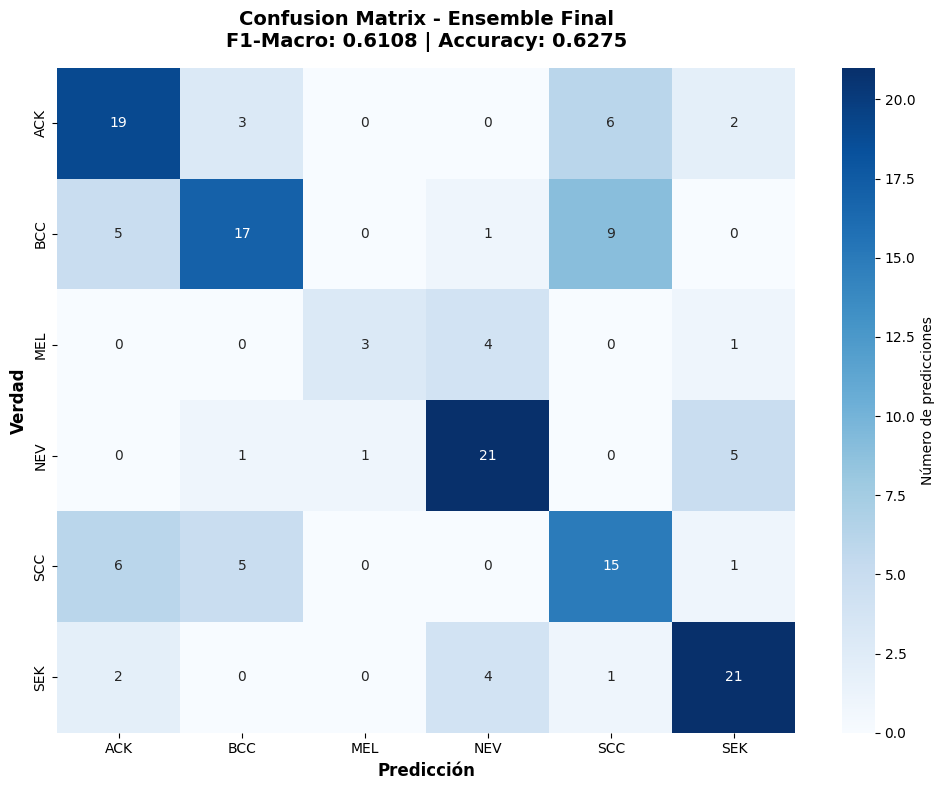


✅ EVALUACIÓN COMPLETADA


In [32]:
# ============================================================================
# ENSEMBLE FINAL - MEJORES MODELOS (ARQUITECTURAS CORRECTAS)
# ============================================================================

import torch
import torch.nn as nn
from torchvision import models
from ultralytics import YOLO
import numpy as np
from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score, 
                            classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 6
class_names = ['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']

print("="*80)
print("🏆 ENSEMBLE FINAL - FOLD 5 DE CADA MODELO")
print("="*80)
print(f"Device: {DEVICE}\n")

# ============================================================================
# FUNCIONES PARA CREAR ARQUITECTURAS (TUS EXACTAS)
# ============================================================================

def crear_resnet18(num_classes, device):
    """Arquitectura EXACTA de entrenamiento"""
    model = models.resnet18(weights=None)
    model.fc = nn.Sequential(
        nn.Dropout(0.3),  # ← TU dropout
        nn.Linear(model.fc.in_features, num_classes)
    )
    return model.to(device)

def crear_densenet121(num_classes, device):
    """Arquitectura EXACTA de entrenamiento"""
    model = models.densenet121(weights=None)
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),  # ← TU dropout
        nn.Linear(model.classifier.in_features, num_classes)
    )
    return model.to(device)

# ============================================================================
# 1. CARGAR RESNET18 FOLD 5
# ============================================================================

print("📌 Cargando ResNet18 Fold 5...")
resnet_model = crear_resnet18(NUM_CLASSES, DEVICE)
resnet_model.load_state_dict(torch.load('ResNet18_5Fold_fold5.pth', map_location=DEVICE))
resnet_model.eval()
print("✅ ResNet18 cargado")

# ============================================================================
# 2. CARGAR DENSENET121 FOLD 5
# ============================================================================

print("📌 Cargando DenseNet121 Fold 5...")
densenet_model = crear_densenet121(NUM_CLASSES, DEVICE)
densenet_model.load_state_dict(torch.load('DenseNet121_5Fold_fold5.pth', map_location=DEVICE))
densenet_model.eval()
print("✅ DenseNet121 cargado")

# ============================================================================
# 3. CARGAR YOLO26X FOLD 5
# ============================================================================

print("📌 Cargando YOLO26x Fold 5...")
yolo_model = YOLO('runs/classify/runs/YOLO26x_Fold5/weights/best.pt')
print("✅ YOLO26x cargado")

# ============================================================================
# 4. INFERENCIA EN TEST - RESNET18
# ============================================================================

print("\n📊 Realizando inferencia con ResNet18...")
resnet_probs = []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(DEVICE)
        outputs = resnet_model(images)
        probs = torch.softmax(outputs, dim=1)
        resnet_probs.append(probs.cpu().numpy())

resnet_probs = np.vstack(resnet_probs)
print(f"✅ ResNet18: {resnet_probs.shape}")

# ============================================================================
# 5. INFERENCIA EN TEST - DENSENET121
# ============================================================================

print("📊 Realizando inferencia con DenseNet121...")
densenet_probs = []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(DEVICE)
        outputs = densenet_model(images)
        probs = torch.softmax(outputs, dim=1)
        densenet_probs.append(probs.cpu().numpy())

densenet_probs = np.vstack(densenet_probs)
print(f"✅ DenseNet121: {densenet_probs.shape}")

# ============================================================================
# 6. INFERENCIA EN TEST - YOLO26X
# ============================================================================

print("📊 Realizando inferencia con YOLO26x...")

# Variable que deberías tener definida antes (RUTA_TEST o TEST_DIR)
RUTA_TEST = "../../Datos/images/SPLIT_MULTICLASE/test"

# Obtener rutas de imágenes en orden
yolo_image_paths = []
for class_folder in sorted(os.listdir(RUTA_TEST)):
    class_path = os.path.join(RUTA_TEST, class_folder)
    if os.path.isdir(class_path):
        for img_name in sorted(os.listdir(class_path)):
            if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                yolo_image_paths.append(os.path.join(class_path, img_name))

# Predicciones YOLO
yolo_probs = []
for img_path in yolo_image_paths:
    results = yolo_model.predict(img_path, verbose=False)
    if hasattr(results[0], 'probs') and results[0].probs is not None:
        probs = results[0].probs.data.cpu().numpy()
    else:
        probs = np.zeros(NUM_CLASSES)
        probs[results[0].probs.top1] = 1.0
    yolo_probs.append(probs)

yolo_probs = np.array(yolo_probs)
print(f"✅ YOLO26x: {yolo_probs.shape}")

# ============================================================================
# 7. ENSEMBLE - SOFT VOTING CON PESOS ÓPTIMOS
# ============================================================================

print(f"\n{'='*80}")
print("🎯 CREANDO ENSEMBLE FINAL (PESOS ÓPTIMOS)")
print(f"{'='*80}")

# Pesos óptimos encontrados (ajusta según tu búsqueda)
w_resnet = 0.0
w_densenet = 0.5
w_yolo = 0.5

print(f"Pesos: ResNet={w_resnet} | DenseNet={w_densenet} | YOLO={w_yolo}")

ensemble_probs = (w_resnet * resnet_probs + 
                  w_densenet * densenet_probs + 
                  w_yolo * yolo_probs)
ensemble_pred = np.argmax(ensemble_probs, axis=1)

# Obtener etiquetas verdaderas
y_true = np.array([label for _, label in test_dataset.samples])

# ============================================================================
# 8. MÉTRICAS DEL ENSEMBLE
# ============================================================================

print("\n📊 MÉTRICAS DEL ENSEMBLE FINAL:\n")

accuracy = accuracy_score(y_true, ensemble_pred)
f1_macro = f1_score(y_true, ensemble_pred, average='macro')
f1_weighted = f1_score(y_true, ensemble_pred, average='weighted')
kappa = cohen_kappa_score(y_true, ensemble_pred)

print(f"{'Accuracy':<15}: {accuracy:.4f}")
print(f"{'F1-Macro':<15}: {f1_macro:.4f}")
print(f"{'F1-Weighted':<15}: {f1_weighted:.4f}")
print(f"{'Cohen Kappa':<15}: {kappa:.4f}")

# ============================================================================
# 9. CLASSIFICATION REPORT
# ============================================================================

print(f"\n{'='*80}")
print("📋 CLASSIFICATION REPORT")
print(f"{'='*80}\n")

print(classification_report(y_true, ensemble_pred, 
                          target_names=class_names, 
                          digits=4))

# ============================================================================
# 10. CONFUSION MATRIX
# ============================================================================

print(f"{'='*80}")
print("📊 CONFUSION MATRIX")
print(f"{'='*80}\n")

cm = confusion_matrix(y_true, ensemble_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names,
            cbar_kws={'label': 'Número de predicciones'})

ax.set_xlabel('Predicción', fontsize=12, fontweight='bold')
ax.set_ylabel('Verdad', fontsize=12, fontweight='bold')
ax.set_title(f'Confusion Matrix - Ensemble Final\nF1-Macro: {f1_macro:.4f} | Accuracy: {accuracy:.4f}', 
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print("✅ EVALUACIÓN COMPLETADA")
print(f"{'='*80}")

## 10. Visualizacion Comparativa Final

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# 1. Barplot comparativo de F1 Macro en TEST (Ensemble de 5 Folds)
# ============================================================
modelos = ['ResNet-18', 'DenseNet-121', 'YOLO26x', 'Ensemble\nFinal']
f1_values = [
    resultados_resnet['metricas_test_ensemble']['f1_macro'],
    resultados_densenet['metricas_test_ensemble']['f1_macro'],
    resultados_yolo['metricas_test_ensemble']['f1_macro'],
    metricas_ensemble_final['f1_macro'],
]
colors = ['#4c72b0', '#dd8452', '#55a868', '#c44e52']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(modelos, f1_values, color=colors, edgecolor='black', linewidth=0.8, width=0.6)
for bar, val in zip(bars, f1_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_ylabel('F1-Score Macro', fontsize=13)
ax.set_title('Comparativa F1 Macro en TEST (Ensemble 5-Fold por modelo)', fontsize=14)
ax.set_ylim(0, max(f1_values) + 0.08)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 2. Barplot multiple: F1, Accuracy, Kappa en TEST
# ============================================================
metricas_sel = ['f1_macro', 'accuracy', 'kappa']
etiquetas_metricas = ['F1 Macro', 'Accuracy', "Cohen's Kappa"]
modelos_cortos = ['ResNet-18', 'DenseNet-121', 'YOLO26x', 'Ensemble Final']

datos = {
    'ResNet-18': resultados_resnet['metricas_test_ensemble'],
    'DenseNet-121': resultados_densenet['metricas_test_ensemble'],
    'YOLO26x': resultados_yolo['metricas_test_ensemble'],
    'Ensemble Final': metricas_ensemble_final,
}

x = np.arange(len(metricas_sel))
width = 0.18
fig, ax = plt.subplots(figsize=(12, 6))

for i, (nombre, metricas) in enumerate(datos.items()):
    valores = [metricas[m] for m in metricas_sel]
    bars = ax.bar(x + i * width, valores, width, label=nombre, color=colors[i], edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(etiquetas_metricas, fontsize=12)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Comparativa de Metricas en TEST (Ensemble 5-Fold)', fontsize=14)
ax.set_ylim(0, 1.0)
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 3. Comparativa de CV (media +/- std) - F1 Macro Validacion
# ============================================================
cv_modelos = ['ResNet-18', 'DenseNet-121', 'YOLO26x']
cv_medias = [
    np.mean([m['f1_macro'] for m in resultados_resnet['metricas_folds']]),
    np.mean([m['f1_macro'] for m in resultados_densenet['metricas_folds']]),
    np.mean([m['f1_macro'] for m in resultados_yolo['metricas_folds']]),
]
cv_stds = [
    np.std([m['f1_macro'] for m in resultados_resnet['metricas_folds']]),
    np.std([m['f1_macro'] for m in resultados_densenet['metricas_folds']]),
    np.std([m['f1_macro'] for m in resultados_yolo['metricas_folds']]),
]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(cv_modelos, cv_medias, yerr=cv_stds, capsize=8,
              color=colors[:3], edgecolor='black', linewidth=0.8, width=0.5,
              error_kw={'linewidth': 2, 'capthick': 2})
for bar, media, std in zip(bars, cv_medias, cv_stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.008,
            f'{media:.4f}\n+/-{std:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylabel('F1-Score Macro', fontsize=13)
ax.set_title('F1 Macro en Validacion (5-Fold CV, media +/- std)', fontsize=14)
ax.set_ylim(0, max(cv_medias) + max(cv_stds) + 0.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 4. Tabla resumen global
# ============================================================
print(f"\n{'='*80}")
print(f"TABLA RESUMEN - RENDIMIENTO EN TEST (Ensemble 5-Fold)")
print(f"{'='*80}")

resumen_global = pd.DataFrame({
    'ResNet-18 (5F)': resultados_resnet['metricas_test_ensemble'],
    'DenseNet-121 (5F)': resultados_densenet['metricas_test_ensemble'],
    'YOLO26x (5F)': resultados_yolo['metricas_test_ensemble'],
    'Ensemble Final': metricas_ensemble_final,
}).T
print(resumen_global.round(4).to_string())

print(f"\n{'='*80}")
print(f"TABLA RESUMEN - CROSS-VALIDATION (Media +/- Std)")
print(f"{'='*80}")

cv_resumen = pd.DataFrame({
    'ResNet-18': {m: f"{np.mean([f[m] for f in resultados_resnet['metricas_folds']]):.4f} +/- {np.std([f[m] for f in resultados_resnet['metricas_folds']]):.4f}" for m in metricas_sel},
    'DenseNet-121': {m: f"{np.mean([f[m] for f in resultados_densenet['metricas_folds']]):.4f} +/- {np.std([f[m] for f in resultados_densenet['metricas_folds']]):.4f}" for m in metricas_sel},
    'YOLO26x': {m: f"{np.mean([f[m] for f in resultados_yolo['metricas_folds']]):.4f} +/- {np.std([f[m] for f in resultados_yolo['metricas_folds']]):.4f}" for m in metricas_sel},
})
print(cv_resumen.to_string())
print(f"{'='*80}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

def visualizar_folds_en_test(test_loader, model_factory, model_name_prefix, num_classes, device, class_names):
    """
    Carga los 5 modelos guardados de los folds y los evalúa TODOS sobre el mismo TEST set.
    Muestra las 5 matrices de confusión una al lado de la otra.
    """
    print(f"\nEvaluando modelos individuales en TEST SET: {model_name_prefix}...")
    
    # 1. Configurar figura
    fig, axes = plt.subplots(1, 5, figsize=(24, 5))
    fig.suptitle(f'Rendimiento en TEST por Fold Individual - {model_name_prefix}', fontsize=16)
    
    # 2. Iterar del 1 al 5
    for i in range(5):
        fold_idx = i + 1
        print(f"  --> Cargando Fold {fold_idx}...", end="\r")
        
        # A) Instanciar limpia
        model, _ = model_factory(num_classes, device)
        
        # B) Cargar pesos
        ruta_modelo = f"{model_name_prefix}_fold{fold_idx}.pth"
        if not os.path.exists(ruta_modelo):
            print(f"    AVISO: No existe {ruta_modelo}")
            continue
            
        model.load_state_dict(torch.load(ruta_modelo, map_location=device))
        model.eval()
        model.to(device)
        
        # C) Predecir en TEST (Siempre el mismo test_loader)
        y_true = []
        y_pred = []
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                y_true.extend(labels.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())
        
        # D) Métricas
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro')
        
        # E) Plot Matriz
        cm = confusion_matrix(y_true, y_pred)
        ax = axes[i]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False, ax=ax,
                   xticklabels=class_names.values(), yticklabels=class_names.values())
        
        ax.set_title(f'Model Fold {fold_idx}\nTest Acc: {acc:.3f} | F1: {f1:.3f}')
        ax.set_xlabel('Predicción')
        if i == 0:
            ax.set_ylabel('Realidad (Test)')
        else:
            ax.set_ylabel('')
            ax.set_yticks([])

    plt.tight_layout()
    plt.show()
    print(f"\nProceso completado. Compara las matrices para ver la diversidad de errores.")

# --- EJECUTAR PARA RESNET Y DENSENET ---

# ResNet18
visualizar_folds_en_test(
    test_loader, 
    crear_resnet18, 
    "ResNet18_5Fold", 
    len(class_names), 
    device, 
    class_names
)

# DenseNet121
visualizar_folds_en_test(
    test_loader, 
    crear_densenet121, 
    "DenseNet121_5Fold", 
    len(class_names), 
    device, 
    class_names
)

In [ ]:
from ultralytics import YOLO
import pandas as pd
import glob

def visualizar_folds_yolo_en_test(test_path, model_path_template, class_names):
    """
    Evalúa 5 modelos YOLO en el Test Set y muestra sus matrices de confusión.
    
    test_path: Ruta a la carpeta de test (debe tener subcarpetas por clase)
    model_path_template: String con formato ej. "runs/classify/runs/YOLO26x_Fold{}/weights/best.pt"
    """
    print(f"\nEvaluando modelos YOLO (5 Folds) en TEST SET: {test_path}...")
    
    # 1. Preparar datos de Test (Listar imágenes y etiquetas reales)
    # Asumimos estructura: test_path/CLASS_NAME/image.jpg
    test_images = []
    y_true = []
    
    # Mapeo inverso de nombre a índice para uniformidad con PyTorch
    # class_names es dict {0: 'ACK', ...} -> invertimos a {'ACK': 0, ...}
    class_to_idx = {v: k for k, v in class_names.items()}
    
    for cls_name in class_names.values():
        cls_folder = os.path.join(test_path, cls_name)
        if not os.path.isdir(cls_folder):
            continue
        # Buscar imágenes
        imgs = glob.glob(os.path.join(cls_folder, "*")) # jpg, png, etc.
        test_images.extend(imgs)
        y_true.extend([class_to_idx[cls_name]] * len(imgs))
        
    print(f"  Total imágenes Test encontradas: {len(test_images)}")

    # 2. Configurar figura
    fig, axes = plt.subplots(1, 5, figsize=(24, 5))
    fig.suptitle(f'Rendimiento en TEST por Fold Individual - YOLOv8', fontsize=16)
    
    # 3. Iterar folds
    for i in range(5):
        fold_idx = i + 1
        model_path = model_path_template.format(fold_idx)
        print(f"  --> Procesando Fold {fold_idx}: {model_path}...", end="\r")
        
        if not os.path.exists(model_path):
            print(f"\n    AVISO: No se encontró {model_path}, saltando...")
            continue
            
        # A) Cargar Modelo
        try:
            model = YOLO(model_path)
        except Exception as e:
            print(f"\n    Error cargando {model_path}: {e}")
            continue
            
        # B) Predecir (Batch inference es más rápido)
        # stream=True ayuda con memoria si hay muchas imágenes, pero verbose=False limpia el output
        results = model.predict(test_images, verbose=False, stream=False)
        
        # C) Extraer predicciones
        y_pred = []
        for r in results:
            # r.probs.top1 da el índice de la clase con mayor probabilidad
            y_pred.append(r.probs.top1)
            
        # D) Métricas
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro')
        
        # E) Plot
        cm = confusion_matrix(y_true, y_pred)
        ax = axes[i]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=ax,
                   xticklabels=class_names.values(), yticklabels=class_names.values())
        
        ax.set_title(f'YOLO Fold {fold_idx}\nTest Acc: {acc:.3f} | F1: {f1:.3f}')
        ax.set_xlabel('Predicción')
        if i == 0:
            ax.set_ylabel('Realidad (Test)')
        else:
            ax.set_ylabel('')
            ax.set_yticks([])

    plt.tight_layout()
    plt.show()
    print(f"\nEvaluación YOLO completada.")

# --- EJECUTAR ---
# Ajusta 'ruta_test' a tu carpeta real de test, ej: "Datos/images/SPLIT_MULTICLASE/test"
ruta_test = f"{RUTA_BASE}/test" 

# Ajusta el template a donde se guardaron tus runs de YOLO
# Según tu ls anterior: runs/classify/runs/YOLO26x_Fold1/weights/best.pt
ruta_modelo_template = "runs/classify/runs/YOLO26x_Fold{}/weights/best.pt"

visualizar_folds_yolo_en_test(
    ruta_test, 
    ruta_modelo_template, 
    class_names
)

🔍 BÚSQUEDA DE PESOS ÓPTIMOS PARA ENSEMBLE

Objetivos:
  1️⃣ Maximizar F1-Macro
  2️⃣ Maximizar Cohen's Kappa
  3️⃣ Maximizar Precision de MEL (clase 2)

📊 Probando combinaciones de pesos (paso 0.1)...
✅ Evaluadas 66 combinaciones

🏆 MEJORES COMBINACIONES ENCONTRADAS

1️⃣ MEJOR F1-MACRO:
   Pesos: ResNet=0.00 | DenseNet=0.50 | YOLO=0.50
   F1-Macro: 0.6108
   Kappa: 0.5426
   MEL Precision: 0.7500

2️⃣ MEJOR KAPPA:
   Pesos: ResNet=0.20 | DenseNet=0.50 | YOLO=0.30
   F1-Macro: 0.6102
   Kappa: 0.5509
   MEL Precision: 0.6000

3️⃣ MEJOR PRECISION MEL:
   Pesos: ResNet=0.00 | DenseNet=0.00 | YOLO=1.00
   F1-Macro: 0.5599
   Kappa: 0.4705
   MEL Precision: 0.7500

📊 TOP 10 COMBINACIONES BALANCEADAS
    (40% F1-Macro + 30% Kappa + 30% MEL Precision)

 w_resnet  w_densenet  w_yolo  f1_macro    kappa  mel_precision  score_combinado
      0.0         0.5     0.5  0.610771 0.542637           0.75         0.632100
      0.1         0.7     0.2  0.609122 0.542301           0.75         0.631339
 

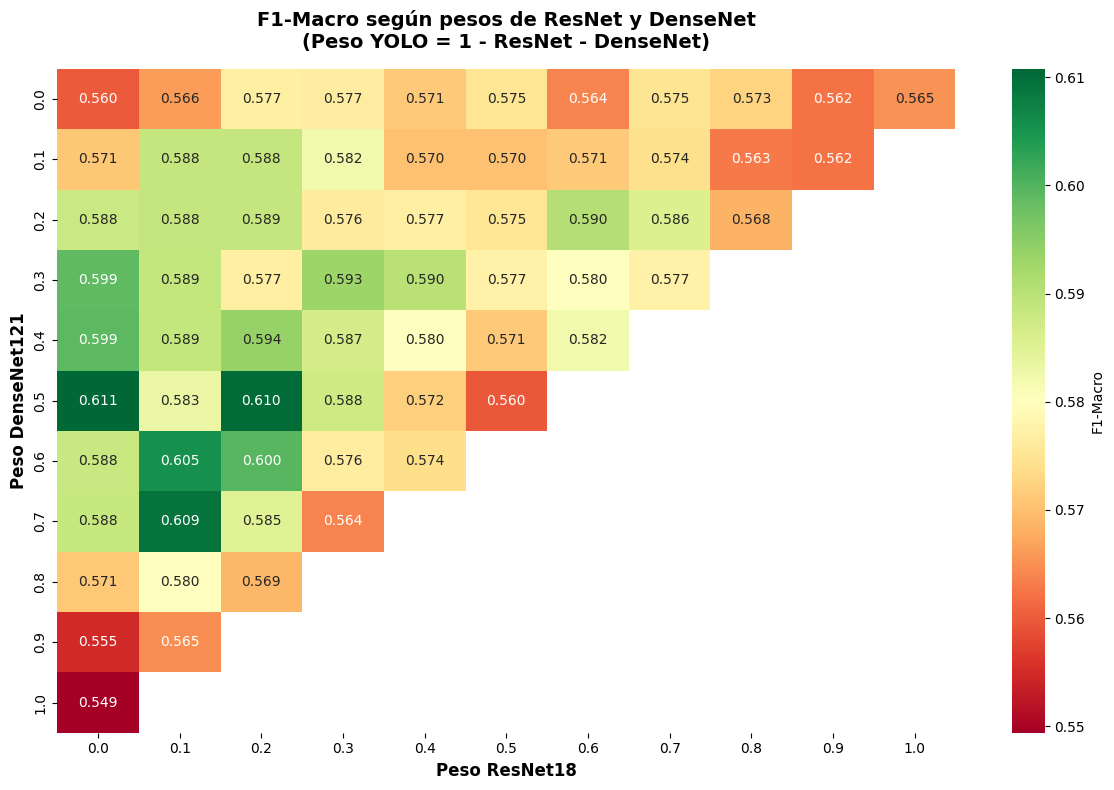


💡 RECOMENDACIÓN FINAL

Para maximizar F1-Macro, Kappa y Precisión de MEL simultáneamente:
  🎯 ResNet18:    0.00
  🎯 DenseNet121: 0.50
  🎯 YOLO26x:     0.50

Métricas esperadas:
  F1-Macro:       0.6108
  Kappa:          0.5426
  MEL Precision:  0.7500

✅ BÚSQUEDA COMPLETADA


In [33]:
# ============================================================================
# BÚSQUEDA DE PESOS ÓPTIMOS PARA ENSEMBLE
# Objetivo: Maximizar F1-Macro, Kappa y Precision de MEL
# ============================================================================

from itertools import product
from sklearn.metrics import precision_score
import pandas as pd

print("="*80)
print("🔍 BÚSQUEDA DE PESOS ÓPTIMOS PARA ENSEMBLE")
print("="*80)
print("\nObjetivos:")
print("  1️⃣ Maximizar F1-Macro")
print("  2️⃣ Maximizar Cohen's Kappa")
print("  3️⃣ Maximizar Precision de MEL (clase 2)")
print("="*80)

# ============================================================================
# GRID SEARCH - Pesos con paso de 0.1
# ============================================================================

print("\n📊 Probando combinaciones de pesos (paso 0.1)...")

# Generar todas las combinaciones que sumen 1.0
step = 0.1
weights_range = [round(x * step, 2) for x in range(0, 11)]  # 0.0 a 1.0

results = []
best_f1 = {'score': 0, 'weights': None, 'kappa': 0, 'mel_prec': 0}
best_kappa = {'score': 0, 'weights': None, 'f1': 0, 'mel_prec': 0}
best_mel_prec = {'score': 0, 'weights': None, 'f1': 0, 'kappa': 0}

total_combinations = 0
for w_resnet in weights_range:
    for w_densenet in weights_range:
        w_yolo = round(1.0 - w_resnet - w_densenet, 2)
        
        # Validar que los pesos sumen 1 y sean válidos
        if w_yolo < 0 or w_yolo > 1.0 or abs(w_resnet + w_densenet + w_yolo - 1.0) > 0.01:
            continue
        
        total_combinations += 1
        
        # Calcular ensemble con estos pesos
        ensemble_probs_weighted = (
            w_resnet * resnet_probs + 
            w_densenet * densenet_probs + 
            w_yolo * yolo_probs
        )
        ensemble_pred_weighted = np.argmax(ensemble_probs_weighted, axis=1)
        
        # Calcular métricas
        f1_macro = f1_score(y_true, ensemble_pred_weighted, average='macro')
        kappa = cohen_kappa_score(y_true, ensemble_pred_weighted)
        
        # Precision específica de MEL (clase 2)
        mel_precision = precision_score(y_true, ensemble_pred_weighted, 
                                       labels=[2], average='macro', zero_division=0)
        
        # Guardar resultados
        results.append({
            'w_resnet': w_resnet,
            'w_densenet': w_densenet,
            'w_yolo': w_yolo,
            'f1_macro': f1_macro,
            'kappa': kappa,
            'mel_precision': mel_precision,
            'score_combinado': 0.4*f1_macro + 0.3*kappa + 0.3*mel_precision  # Score ponderado
        })
        
        # Actualizar mejores
        if f1_macro > best_f1['score']:
            best_f1 = {
                'score': f1_macro,
                'weights': (w_resnet, w_densenet, w_yolo),
                'kappa': kappa,
                'mel_prec': mel_precision
            }
        
        if kappa > best_kappa['score']:
            best_kappa = {
                'score': kappa,
                'weights': (w_resnet, w_densenet, w_yolo),
                'f1': f1_macro,
                'mel_prec': mel_precision
            }
        
        if mel_precision > best_mel_prec['score']:
            best_mel_prec = {
                'score': mel_precision,
                'weights': (w_resnet, w_densenet, w_yolo),
                'f1': f1_macro,
                'kappa': kappa
            }

print(f"✅ Evaluadas {total_combinations} combinaciones")

# ============================================================================
# RESULTADOS - MEJORES COMBINACIONES
# ============================================================================

print(f"\n{'='*80}")
print("🏆 MEJORES COMBINACIONES ENCONTRADAS")
print(f"{'='*80}\n")

print("1️⃣ MEJOR F1-MACRO:")
print(f"   Pesos: ResNet={best_f1['weights'][0]:.2f} | "
      f"DenseNet={best_f1['weights'][1]:.2f} | YOLO={best_f1['weights'][2]:.2f}")
print(f"   F1-Macro: {best_f1['score']:.4f}")
print(f"   Kappa: {best_f1['kappa']:.4f}")
print(f"   MEL Precision: {best_f1['mel_prec']:.4f}\n")

print("2️⃣ MEJOR KAPPA:")
print(f"   Pesos: ResNet={best_kappa['weights'][0]:.2f} | "
      f"DenseNet={best_kappa['weights'][1]:.2f} | YOLO={best_kappa['weights'][2]:.2f}")
print(f"   F1-Macro: {best_kappa['f1']:.4f}")
print(f"   Kappa: {best_kappa['score']:.4f}")
print(f"   MEL Precision: {best_kappa['mel_prec']:.4f}\n")

print("3️⃣ MEJOR PRECISION MEL:")
print(f"   Pesos: ResNet={best_mel_prec['weights'][0]:.2f} | "
      f"DenseNet={best_mel_prec['weights'][1]:.2f} | YOLO={best_mel_prec['weights'][2]:.2f}")
print(f"   F1-Macro: {best_mel_prec['f1']:.4f}")
print(f"   Kappa: {best_mel_prec['kappa']:.4f}")
print(f"   MEL Precision: {best_mel_prec['score']:.4f}\n")

# ============================================================================
# TOP 10 COMBINACIONES BALANCEADAS
# ============================================================================

df_results = pd.DataFrame(results)
df_results = df_results.sort_values('score_combinado', ascending=False)

print(f"{'='*80}")
print("📊 TOP 10 COMBINACIONES BALANCEADAS")
print("    (40% F1-Macro + 30% Kappa + 30% MEL Precision)")
print(f"{'='*80}\n")

print(df_results.head(10).to_string(index=False))

# ============================================================================
# VISUALIZACIÓN - HEATMAP DE F1-MACRO
# ============================================================================

print(f"\n{'='*80}")
print("📈 Generando visualización...")
print(f"{'='*80}")

# Crear matriz para heatmap
pivot_data = df_results.pivot_table(
    values='f1_macro',
    index='w_densenet',
    columns='w_resnet',
    aggfunc='max'
)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='RdYlGn', 
            cbar_kws={'label': 'F1-Macro'}, ax=ax)

ax.set_xlabel('Peso ResNet18', fontsize=12, fontweight='bold')
ax.set_ylabel('Peso DenseNet121', fontsize=12, fontweight='bold')
ax.set_title('F1-Macro según pesos de ResNet y DenseNet\n(Peso YOLO = 1 - ResNet - DenseNet)', 
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

# ============================================================================
# RECOMENDACIÓN FINAL
# ============================================================================

print(f"\n{'='*80}")
print("💡 RECOMENDACIÓN FINAL")
print(f"{'='*80}\n")

# Usar la mejor combinación balanceada
best_balanced = df_results.iloc[0]

print(f"Para maximizar F1-Macro, Kappa y Precisión de MEL simultáneamente:")
print(f"  🎯 ResNet18:    {best_balanced['w_resnet']:.2f}")
print(f"  🎯 DenseNet121: {best_balanced['w_densenet']:.2f}")
print(f"  🎯 YOLO26x:     {best_balanced['w_yolo']:.2f}")
print(f"\nMétricas esperadas:")
print(f"  F1-Macro:       {best_balanced['f1_macro']:.4f}")
print(f"  Kappa:          {best_balanced['kappa']:.4f}")
print(f"  MEL Precision:  {best_balanced['mel_precision']:.4f}")

print(f"\n{'='*80}")
print("✅ BÚSQUEDA COMPLETADA")
print(f"{'='*80}")

📌 Cargando ResNet18 Fold 5...
✅ ResNet18: (153, 6)

📌 Cargando DenseNet121 Ensemble (5 folds)...
  Fold 1... ✓
  Fold 2... ✓
  Fold 3... ✓
  Fold 4... ✓
  Fold 5... ✓
✅ DenseNet Ensemble: (153, 6)

📌 Cargando YOLO26x Fold 5...
✅ YOLO26x: (153, 6)

📊 CURVAS ROC - ONE VS ALL

📈 Calculando AUC por clase...

ResNet18 (Fold5):
  ACK: 0.8190
  BCC: 0.8729
  MEL: 0.9414
  NEV: 0.9054
  SCC: 0.7575
  SEK: 0.9186
  MACRO: 0.8691

DenseNet121 (Ensemble 5 folds):
  ACK: 0.8542
  BCC: 0.8528
  MEL: 0.8871
  NEV: 0.9049
  SCC: 0.7763
  SEK: 0.9291
  MACRO: 0.8674

YOLO26x (Fold5):
  ACK: 0.8425
  BCC: 0.8807
  MEL: 0.8345
  NEV: 0.8851
  SCC: 0.8128
  SEK: 0.9189
  MACRO: 0.8624

Ensemble Óptimo (50% Dense + 50% YOLO):
  ACK: 0.8615
  BCC: 0.8742
  MEL: 0.8767
  NEV: 0.9051
  SCC: 0.8233
  SEK: 0.9309
  MACRO: 0.8786

📋 TABLA: AUC POR CLASE

                                           ACK     BCC     MEL     NEV     SCC     SEK   MACRO
ResNet18 (Fold5)                        0.8190  0.8729  0.9414  

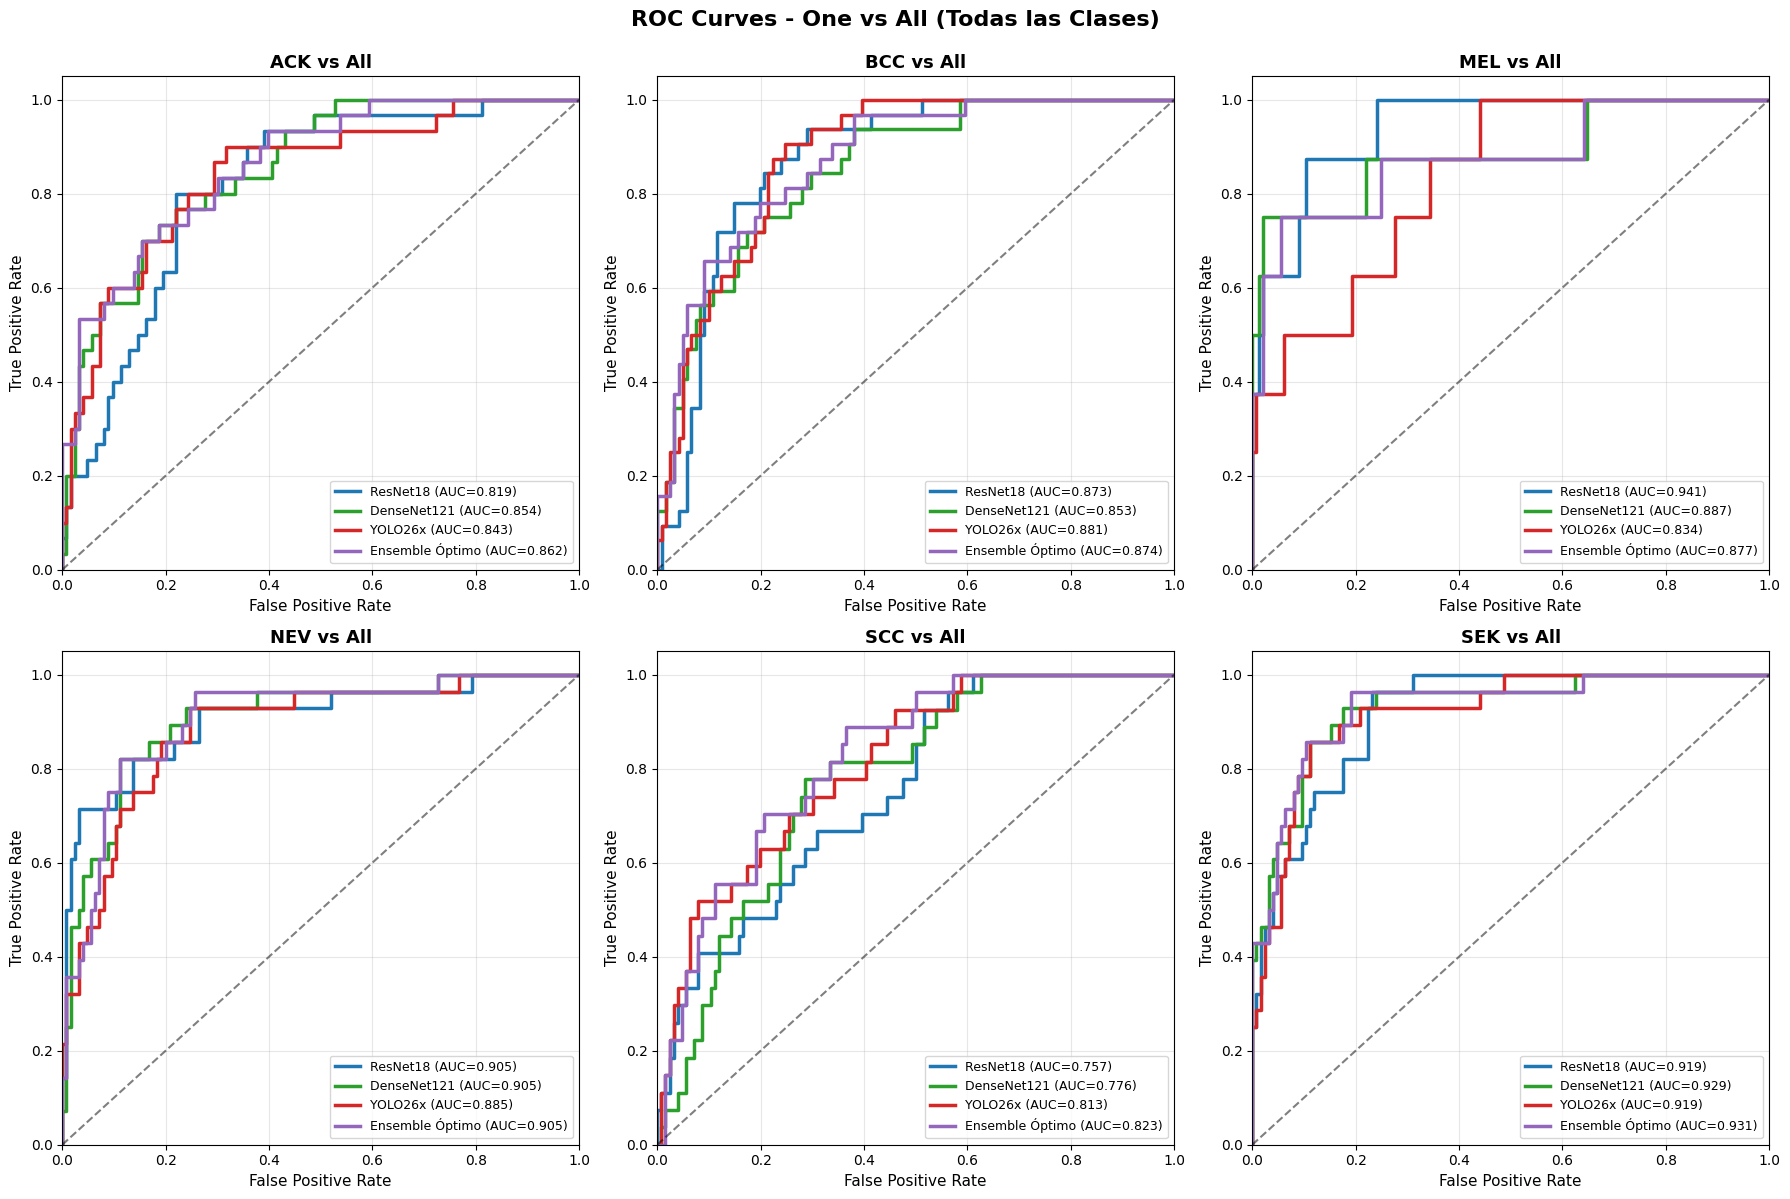

📊 Generando gráfico comparativo de barras...



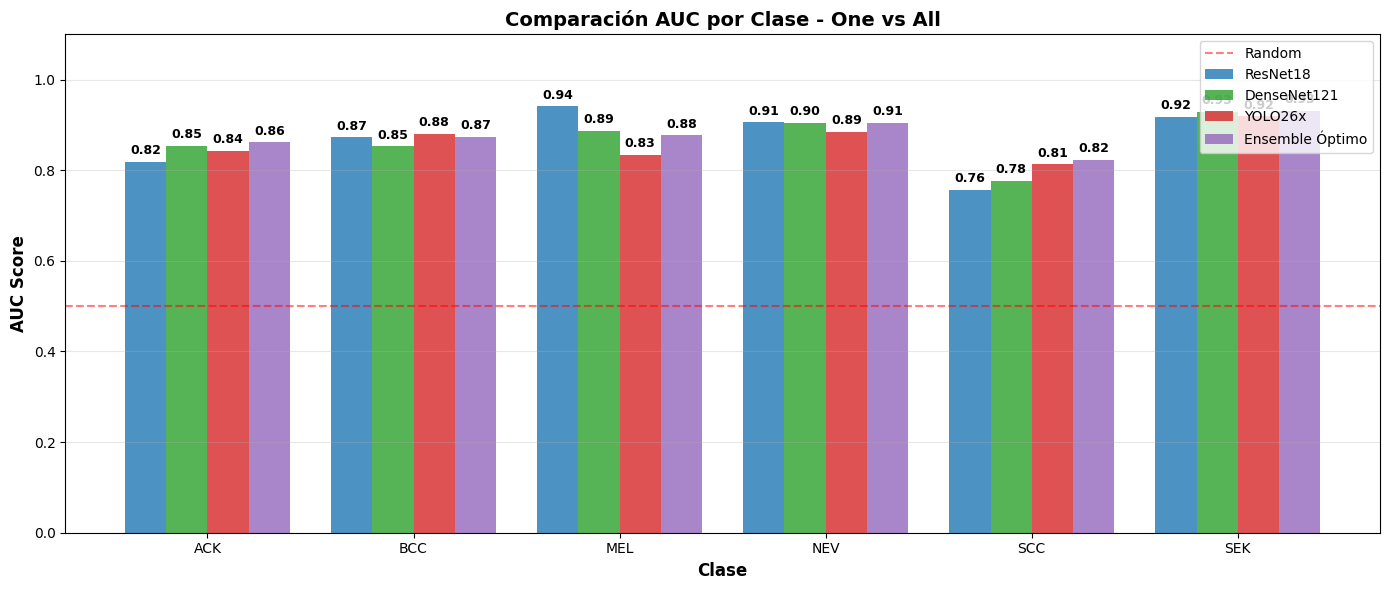

📊 Generando heatmap de AUC...



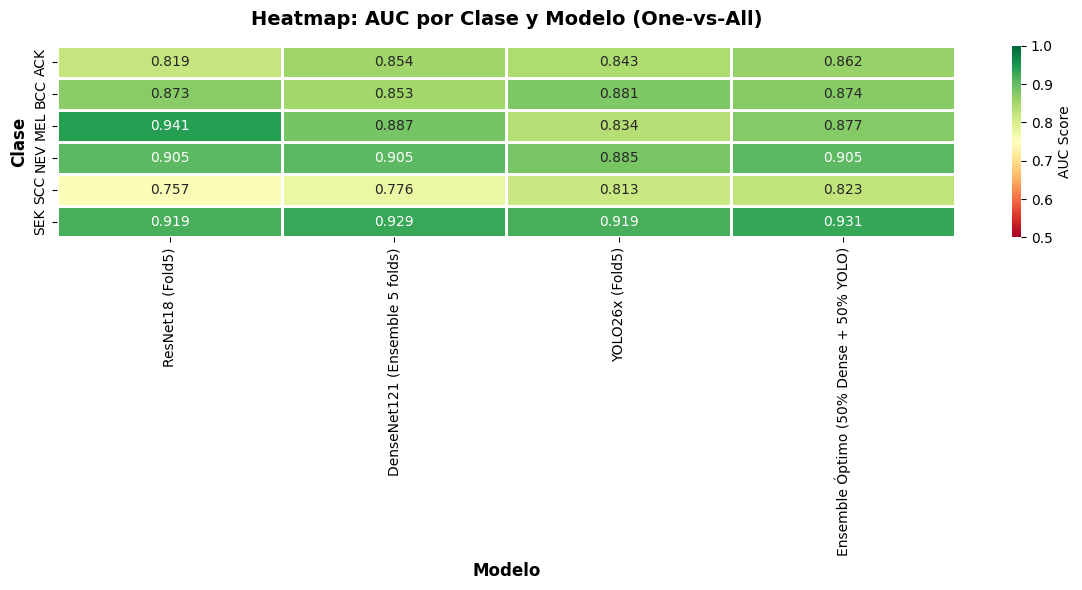

🏆 MEJORES MODELOS

🥇 Mejor AUC Macro: Ensemble Óptimo (50% Dense + 50% YOLO)
   Score: 0.8786

🎯 Mejor modelo por clase:
  ACK: Ensemble Óptimo                (AUC=0.8615)
  BCC: YOLO26x                        (AUC=0.8807)
  MEL: ResNet18                       (AUC=0.9414)
  NEV: ResNet18                       (AUC=0.9054)
  SCC: Ensemble Óptimo                (AUC=0.8233)
  SEK: Ensemble Óptimo                (AUC=0.9309)

✅ ANÁLISIS ROC COMPLETADO


In [36]:
# ============================================================================
# CÓDIGO COMPLETO - COMPARACIÓN ROC (ARQUITECTURAS CORRECTAS)
# ============================================================================

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize




# ============================================================================
# FUNCIONES DE CREACIÓN (TUS ARQUITECTURAS EXACTAS)
# ============================================================================

def crear_resnet18(num_classes, device):
    """Arquitectura EXACTA usada en entrenamiento"""
    model = models.resnet18(weights=None)  # Sin pretrain para cargar pesos
    
    # Mismo dropout que entrenamiento
    model.fc = nn.Sequential(
        nn.Dropout(0.3),  # ← TU dropout
        nn.Linear(model.fc.in_features, num_classes)
    )
    
    return model.to(device)

def crear_densenet121(num_classes, device):
    """Arquitectura EXACTA usada en entrenamiento"""
    model = models.densenet121(weights=None)  # Sin pretrain para cargar pesos
    
    # Mismo dropout que entrenamiento
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),  # ← TU dropout
        nn.Linear(model.classifier.in_features, num_classes)
    )
    
    return model.to(device)



# ============================================================================
# 1. CARGAR E INFERIR RESNET18 FOLD 5
# ============================================================================

print("📌 Cargando ResNet18 Fold 5...")
resnet_model = crear_resnet18(NUM_CLASSES, DEVICE)
resnet_model.load_state_dict(torch.load('ResNet18_5Fold_fold5.pth', map_location=DEVICE))
resnet_model.eval()

resnet_probs = []
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(DEVICE)
        outputs = resnet_model(images)
        probs = torch.softmax(outputs, dim=1)
        resnet_probs.append(probs.cpu().numpy())

resnet_probs = np.vstack(resnet_probs)
print(f"✅ ResNet18: {resnet_probs.shape}\n")

del resnet_model
torch.cuda.empty_cache()
gc.collect()

# ============================================================================
# 2. CARGAR E INFERIR DENSENET121 (ENSEMBLE 5 FOLDS)
# ============================================================================

print("📌 Cargando DenseNet121 Ensemble (5 folds)...")
densenet_probs_all_folds = []

for fold in range(1, 6):
    print(f"  Fold {fold}...", end=" ")
    
    model = crear_densenet121(NUM_CLASSES, DEVICE)
    model.load_state_dict(torch.load(f'DenseNet121_5Fold_fold{fold}.pth', map_location=DEVICE))
    model.eval()
    
    fold_probs = []
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(DEVICE)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            fold_probs.append(probs.cpu().numpy())
    
    fold_probs = np.vstack(fold_probs)
    densenet_probs_all_folds.append(fold_probs)
    print("✓")
    
    del model
    torch.cuda.empty_cache()
    gc.collect()

densenet_ensemble_probs = np.mean(densenet_probs_all_folds, axis=0)
print(f"✅ DenseNet Ensemble: {densenet_ensemble_probs.shape}\n")

# ============================================================================
# 3. CARGAR E INFERIR YOLO26X FOLD 5
# ============================================================================

print("📌 Cargando YOLO26x Fold 5...")
yolo_model = YOLO('runs/classify/runs/YOLO26x_Fold5/weights/best.pt')

yolo_image_paths = []
for class_folder in sorted(os.listdir(TEST_DIR)):
    class_path = os.path.join(TEST_DIR, class_folder)
    if os.path.isdir(class_path):
        for img_name in sorted(os.listdir(class_path)):
            if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                yolo_image_paths.append(os.path.join(class_path, img_name))

yolo_probs = []
for img_path in yolo_image_paths:
    results = yolo_model.predict(img_path, verbose=False)
    if hasattr(results[0], 'probs') and results[0].probs is not None:
        probs = results[0].probs.data.cpu().numpy()
    else:
        probs = np.zeros(NUM_CLASSES)
        probs[results[0].probs.top1] = 1.0
    yolo_probs.append(probs)

yolo_probs = np.array(yolo_probs)
print(f"✅ YOLO26x: {yolo_probs.shape}\n")

print("="*80)
print("📊 CURVAS ROC - ONE VS ALL")
print("="*80)
# Binarizar etiquetas (One-vs-Rest)
y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3, 4, 5])
n_classes = 6
# ============================================================================
# CANDIDATOS
# ============================================================================
candidatos = {
    'ResNet18 (Fold5)': resnet_probs,
    'DenseNet121 (Ensemble 5 folds)': densenet_ensemble_probs,
    'YOLO26x (Fold5)': yolo_probs,
    'Ensemble Óptimo (50% Dense + 50% YOLO)': 
        0.5 * densenet_ensemble_probs + 0.5 * yolo_probs
}
# ============================================================================
# CALCULAR AUC PARA CADA CLASE
# ============================================================================
print("\n📈 Calculando AUC por clase...\n")
resultados_por_clase = {nombre: {} for nombre in candidatos.keys()}
for nombre, probs in candidatos.items():
    print(f"{nombre}:")
    for i, clase in enumerate(class_names):
        auc_clase = roc_auc_score(y_true_bin[:, i], probs[:, i])
        resultados_por_clase[nombre][clase] = auc_clase
        print(f"  {clase}: {auc_clase:.4f}")
    
    # AUC Macro (promedio simple)
    auc_macro = np.mean(list(resultados_por_clase[nombre].values()))
    resultados_por_clase[nombre]['MACRO'] = auc_macro
    print(f"  MACRO: {auc_macro:.4f}\n")
# ============================================================================
# TABLA COMPARATIVA POR CLASE
# ============================================================================
df_resultados = pd.DataFrame(resultados_por_clase).T
print("="*80)
print("📋 TABLA: AUC POR CLASE")
print("="*80 + "\n")
print(df_resultados.round(4).to_string())
# ============================================================================
# GRÁFICO 1: ROC CURVES - GRID (UNA SUBFIGURA POR CLASE)
# ============================================================================
print(f"\n{'='*80}")
print("📊 Generando ROC curves (One-vs-All)...")
print(f"{'='*80}\n")
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()
colores = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd']
for idx, clase_nombre in enumerate(class_names):
    ax = axes[idx]
    
    for (nombre, probs), color in zip(candidatos.items(), colores):
        # Calcular ROC
        fpr, tpr, _ = roc_curve(y_true_bin[:, idx], probs[:, idx])
        auc_score = auc(fpr, tpr)
        
        # Plotear
        ax.plot(fpr, tpr, color=color, lw=2.5,
                label=f'{nombre.split("(")[0].strip()} (AUC={auc_score:.3f})')
    
    # Línea diagonal (random)
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5)
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'{clase_nombre} vs All', fontsize=13, fontweight='bold')
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)
plt.suptitle('ROC Curves - One vs All (Todas las Clases)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()
# ============================================================================
# GRÁFICO 2: BARRAS - AUC POR CLASE Y MODELO
# ============================================================================
print("📊 Generando gráfico comparativo de barras...\n")
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(class_names))
width = 0.2
for i, (nombre, color) in enumerate(zip(candidatos.keys(), colores)):
    valores = [resultados_por_clase[nombre][clase] for clase in class_names]
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, valores, width, label=nombre.split('(')[0].strip(), 
                   color=color, alpha=0.8)
    
    # Valores sobre barras
    for bar, valor in zip(bars, valores):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{valor:.2f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('AUC Score', fontsize=12, fontweight='bold')
ax.set_xlabel('Clase', fontsize=12, fontweight='bold')
ax.set_title('Comparación AUC por Clase - One vs All', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.set_ylim(0, 1.1)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random')
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
# ============================================================================
# GRÁFICO 3: HEATMAP - AUC POR MODELO Y CLASE
# ============================================================================
print("📊 Generando heatmap de AUC...\n")
import seaborn as sns
# Preparar datos (sin columna MACRO)
df_heatmap = df_resultados[class_names].T
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(df_heatmap, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0.5, vmax=1.0, center=0.75,
            cbar_kws={'label': 'AUC Score'},
            linewidths=1, linecolor='white')
ax.set_xlabel('Modelo', fontsize=12, fontweight='bold')
ax.set_ylabel('Clase', fontsize=12, fontweight='bold')
ax.set_title('Heatmap: AUC por Clase y Modelo (One-vs-All)', 
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
# ============================================================================
# MEJOR MODELO POR MÉTRICA
# ============================================================================
print(f"{'='*80}")
print("🏆 MEJORES MODELOS")
print(f"{'='*80}\n")
mejor_macro = df_resultados['MACRO'].idxmax()
print(f"🥇 Mejor AUC Macro: {mejor_macro}")
print(f"   Score: {df_resultados.loc[mejor_macro, 'MACRO']:.4f}\n")
# Mejor por cada clase
print("🎯 Mejor modelo por clase:")
for clase in class_names:
    mejor = df_resultados[clase].idxmax()
    score = df_resultados.loc[mejor, clase]
    print(f"  {clase}: {mejor.split('(')[0].strip():30s} (AUC={score:.4f})")
print(f"\n{'='*80}")
print("✅ ANÁLISIS ROC COMPLETADO")
print(f"{'='*80}")